In [1]:
results = {
    'KNN15' : [],
    'MEAN_MODE' : [],
    'MEDIAN_MODE' : [],
    'MICE' : [],
    'NUL_MODE' : [],
    'missForest' : []
}

In [101]:
results_wmt = {
    'KNN15' : [],
    'MEAN_MODE' : [],
    'MEDIAN_MODE' : [],
    'MICE' : [],
    'NUL_MODE' : [],
    'missForest' : []
}

In [2]:
from scipy.stats import rankdata  # удобно ранжировать строки
import numpy as np

# Пример данных (N строк, M подходов)
data = [
    [0.9, 0.7, 0.8],     # строка 1
    [0.85, 0.9, 0.88],   # строка 2
    [0.92, 0.91, 0.93],  # строка 3
]

arr = np.array(data)

# Массив рангов той же формы N×M
# rankdata присваивает ранг 1 лучшему; параметр -x для "максимум = лучший"
ranks = np.apply_along_axis(lambda row: rankdata(-row, method='average'), axis=1, arr=arr)

# Средний ранг для каждого подхода
mean_ranks = ranks.mean(axis=0)

print("Матрица рангов:")
print(ranks)
print("Средние ранги подходов:")
print(mean_ranks)

Матрица рангов:
[[1. 3. 2.]
 [3. 1. 2.]
 [2. 3. 1.]]
Средние ранги подходов:
[2.         2.33333333 1.66666667]


In [76]:
import pandas as pd

linear = pd.read_csv('linear.csv')

In [77]:
linear.columns

Index(['type_propusk', 'method_zapolnenia', 'name_dataset', 'model', 'RMSE',
       'MAE', 'R2', 'Accuracy', 'Precision', 'Recall', 'F1', 'fit_time',
       'time_score'],
      dtype='object')

In [78]:
linear = linear.drop(['Recall', 'Precision', 'fit_time', 'time_score'], axis = 1)

In [79]:
linear.head()

,type_propusk,method_zapolnenia,name_dataset,model,RMSE,MAE,R2,Accuracy,F1
0,MAR_5,MEAN_MODE,2dplanes_binclass_binaryClass.csv,Linear_Classifier,NaN,NaN,NaN,0.814536,0.814535
1,MAR_5,MEAN_MODE,2dplanes_regression_y.csv,Linear_Regressor,2.647006,2.089475,0.636595,NaN,NaN
2,MAR_5,MEAN_MODE,abalone_binclass_binaryClass.csv,Linear_Classifier,NaN,NaN,NaN,0.769687,0.769364
3,MAR_5,MEAN_MODE,ailerons_binclass_binaryClass.csv,Linear_Classifier,NaN,NaN,NaN,0.861527,0.857090
4,MAR_5,MEAN_MODE,Ailerons_regression_goal.csv,Linear_Regressor,0.000194,0.000141,0.766477,NaN,NaN


In [80]:
mask = ~linear['F1'].isna()
mask

0        True
1       False
2        True
3        True
4       False
        ...  
6293    False
6294     True
6295     True
6296     True
6297    False
Name: F1, Length: 6298, dtype: bool

In [81]:
linear_classification = linear.loc[mask,:]
linear_classification = linear_classification.drop(['RMSE','MAE', 'R2'], axis = 1)

In [82]:
linear_classification

,type_propusk,method_zapolnenia,name_dataset,model,Accuracy,F1
0,MAR_5,MEAN_MODE,2dplanes_binclass_binaryClass.csv,Linear_Classifier,0.814536,0.814535
2,MAR_5,MEAN_MODE,abalone_binclass_binaryClass.csv,Linear_Classifier,0.769687,0.769364
3,MAR_5,MEAN_MODE,ailerons_binclass_binaryClass.csv,Linear_Classifier,0.861527,0.857090
5,MAR_5,MEAN_MODE,analcatdata_supreme_binclass_binaryClass.csv,Linear_Classifier,0.889154,0.879979
8,MAR_5,MEAN_MODE,bank8FM_binclass_binaryClass.csv,Linear_Classifier,0.922485,0.919182
...,...,...,...,...,...,...
6289,MNAR_15,KNN15,spambase_binclass_class.csv,Linear_Classifier,0.889368,0.882606
6292,MNAR_15,KNN15,waveform-5000_multiclass_class.csv,Linear_Classifier,0.854000,0.853869
6294,MNAR_15,KNN15,wine_quality_regression_quality.csv,Linear_Classifier,0.541481,0.214511
6295,MNAR_15,KNN15,yeast_ml8_binclass_class14.csv,Linear_Classifier,0.972277,0.518796


In [83]:
linear_regression = linear.loc[~mask,:]
linear_regression = linear_regression.drop(['Accuracy', 'F1'], axis = 1)

In [84]:
linear_regression.head()

,type_propusk,method_zapolnenia,name_dataset,model,RMSE,MAE,R2
1,MAR_5,MEAN_MODE,2dplanes_regression_y.csv,Linear_Regressor,2.647006,2.089475,6.365946e-01
4,MAR_5,MEAN_MODE,Ailerons_regression_goal.csv,Linear_Regressor,0.000194,0.000141,7.664773e-01
6,MAR_5,MEAN_MODE,analcatdata_supreme_regression_Log_exposure.csv,Linear_Regressor,0.611963,0.561577,-1.337802e+29
7,MAR_5,MEAN_MODE,bank32nh_regression_rej.csv,Linear_Regressor,0.086215,0.060215,4.976739e-01
9,MAR_5,MEAN_MODE,bank8FM_regression_rej.csv,Linear_Regressor,0.053688,0.034898,8.749276e-01


In [85]:
#tem = linear_classification.copy()
custom_order = ['MAR_5', 'MAR_15', 'MAR_30', 'MAR_50', 'MCAR_5', 'MCAR_15', 'MCAR_30', 'MCAR_50','MNAR_5', 'MNAR_15', 'MNAR_30', 'MNAR_50']
order_dict = {value: i for i, value in enumerate(custom_order)}
linear_classification = linear_classification.sort_values(
    by=['type_propusk', 'name_dataset'],
    key=lambda x: x.map(order_dict) if x.name == 'type_propusk' else x
)
linear_classification.index =  [i for i in range(0, 3395)]
linear_classification.head(10)

,type_propusk,method_zapolnenia,name_dataset,model,Accuracy,F1
0,MAR_5,MEAN_MODE,2dplanes_binclass_binaryClass.csv,Linear_Classifier,0.814536,0.814535
1,MAR_5,MEDIAN_MODE,2dplanes_binclass_binaryClass.csv,Linear_Classifier,0.814536,0.814535
2,MAR_5,MICE,2dplanes_binclass_binaryClass.csv,Linear_Classifier,0.837348,0.837345
3,MAR_5,missForest,2dplanes_binclass_binaryClass.csv,Linear_Classifier,0.819466,0.819466
4,MAR_5,NUL_MODE,2dplanes_binclass_binaryClass.csv,Linear_Classifier,0.814536,0.814535
5,MAR_5,KNN15,2dplanes_binclass_binaryClass.csv,Linear_Classifier,0.825059,0.825057
6,MAR_5,MEAN_MODE,BNG(breast-w)_binclass_Class.csv,Linear_Classifier,0.976630,0.974099
7,MAR_5,MEDIAN_MODE,BNG(breast-w)_binclass_Class.csv,Linear_Classifier,0.976020,0.973410
8,MAR_5,MICE,BNG(breast-w)_binclass_Class.csv,Linear_Classifier,0.979779,0.977589
9,MAR_5,missForest,BNG(breast-w)_binclass_Class.csv,Linear_Classifier,0.976731,0.974212


In [86]:
#tem = linear_classification.copy()
custom_order = ['MAR_5', 'MAR_15', 'MAR_30', 'MAR_50', 'MCAR_5', 'MCAR_15', 'MCAR_30', 'MCAR_50','MNAR_5', 'MNAR_15', 'MNAR_30', 'MNAR_50']
order_dict = {value: i for i, value in enumerate(custom_order)}
linear_regression = linear_regression.sort_values(
    by=['type_propusk', 'name_dataset'],
    key=lambda x: x.map(order_dict) if x.name == 'type_propusk' else x
)

linear_regression.head(10)

,type_propusk,method_zapolnenia,name_dataset,model,RMSE,MAE,R2
1,MAR_5,MEAN_MODE,2dplanes_regression_y.csv,Linear_Regressor,2.647006,2.089475,0.636595
1151,MAR_5,MEDIAN_MODE,2dplanes_regression_y.csv,Linear_Regressor,2.647006,2.089475,0.636595
2301,MAR_5,MICE,2dplanes_regression_y.csv,Linear_Regressor,2.380148,1.919647,0.706239
3419,MAR_5,missForest,2dplanes_regression_y.csv,Linear_Regressor,2.650748,2.091318,0.635649
4571,MAR_5,NUL_MODE,2dplanes_regression_y.csv,Linear_Regressor,2.647006,2.089475,0.636595
5723,MAR_5,KNN15,2dplanes_regression_y.csv,Linear_Regressor,2.531781,2.024874,0.667596
4,MAR_5,MEAN_MODE,Ailerons_regression_goal.csv,Linear_Regressor,0.000194,0.000141,0.766477
1154,MAR_5,MEDIAN_MODE,Ailerons_regression_goal.csv,Linear_Regressor,0.000194,0.000141,0.766477
2304,MAR_5,MICE,Ailerons_regression_goal.csv,Linear_Regressor,0.000173,0.000128,0.813477
3422,MAR_5,missForest,Ailerons_regression_goal.csv,Linear_Regressor,0.000184,0.000136,0.788906


<font size="6">Турниры.</font>

<font size="6">Linear.</font>

<font size="4">Классификация.</font>

<font size="6">F1.</font>

In [87]:
tur_1 = linear_classification.copy()

In [88]:
tur_1 = tur_1.drop('Accuracy', axis = 1)
tur_1.head(10)

,type_propusk,method_zapolnenia,name_dataset,model,F1
0,MAR_5,MEAN_MODE,2dplanes_binclass_binaryClass.csv,Linear_Classifier,0.814535
1,MAR_5,MEDIAN_MODE,2dplanes_binclass_binaryClass.csv,Linear_Classifier,0.814535
2,MAR_5,MICE,2dplanes_binclass_binaryClass.csv,Linear_Classifier,0.837345
3,MAR_5,missForest,2dplanes_binclass_binaryClass.csv,Linear_Classifier,0.819466
4,MAR_5,NUL_MODE,2dplanes_binclass_binaryClass.csv,Linear_Classifier,0.814535
5,MAR_5,KNN15,2dplanes_binclass_binaryClass.csv,Linear_Classifier,0.825057
6,MAR_5,MEAN_MODE,BNG(breast-w)_binclass_Class.csv,Linear_Classifier,0.974099
7,MAR_5,MEDIAN_MODE,BNG(breast-w)_binclass_Class.csv,Linear_Classifier,0.973410
8,MAR_5,MICE,BNG(breast-w)_binclass_Class.csv,Linear_Classifier,0.977589
9,MAR_5,missForest,BNG(breast-w)_binclass_Class.csv,Linear_Classifier,0.974212


In [89]:
new_df_1 = tur_1.pivot_table(index=['type_propusk', 'name_dataset'], 
                        columns='method_zapolnenia', 
                        values='F1').reset_index()

# 3. Убираем название иерархии столбцов для красоты
new_df_1.columns.name = None
new_df_1 = new_df_1.fillna(0)
# Вывод результата
print(new_df_1)


    type_propusk                                     name_dataset     KNN15  \
0         MAR_15                2dplanes_binclass_binaryClass.csv  0.799937   
1         MAR_15                 BNG(breast-w)_binclass_Class.csv  0.969160   
2         MAR_15            JapaneseVowels_multiclass_speaker.csv  0.894655   
3         MAR_15                 abalone_binclass_binaryClass.csv  0.775706   
4         MAR_15                ailerons_binclass_binaryClass.csv  0.852159   
..           ...                                              ...       ...   
619      MNAR_50                      spambase_binclass_class.csv  0.000000   
620      MNAR_50               waveform-5000_multiclass_class.csv  0.000000   
621      MNAR_50              wine_quality_regression_quality.csv  0.000000   
622      MNAR_50                   yeast_ml8_binclass_class14.csv  0.000000   
623      MNAR_50  yeast_multiclass_class_protein_localization.csv  0.000000   

     MEAN_MODE  MEDIAN_MODE      MICE  NUL_MODE  mi

In [90]:
new_df_1.columns

Index(['type_propusk', 'name_dataset', 'KNN15', 'MEAN_MODE', 'MEDIAN_MODE',
       'MICE', 'NUL_MODE', 'missForest'],
      dtype='object')

In [91]:
import numpy as np

temp = new_df_1[['KNN15', 'MEAN_MODE', 'MEDIAN_MODE','MICE', 'NUL_MODE', 'missForest']]
arr = np.array(temp)

# Массив рангов той же формы N×M
# rankdata присваивает ранг 1 лучшему; параметр -x для "максимум = лучший"
ranks_F = np.apply_along_axis(lambda row: rankdata(-row, method='ordinal'), axis=1, arr=arr)

# Средний ранг для каждого подхода
mean_ranks_F = ranks_F.mean(axis=0)

print("Матрица рангов:")
print(ranks_F)
print("Средние ранги подходов:")
for i in range(len(temp.columns)):
    print(f'{temp.columns[i]} : {mean_ranks_F[i]}')

Матрица рангов:
[[2 3 4 1 5 6]
 [2 3 5 1 6 4]
 [1 4 5 2 6 3]
 ...
 [6 4 3 1 5 2]
 [6 5 4 1 2 3]
 [5 2 3 6 4 1]]
Средние ранги подходов:
KNN15 : 4.168269230769231
MEAN_MODE : 3.264423076923077
MEDIAN_MODE : 3.921474358974359
MICE : 1.4903846153846154
NUL_MODE : 4.798076923076923
missForest : 3.3573717948717947


In [20]:
for i in range(len(temp.columns)):
    results[temp.columns[i]].append(mean_ranks_F[i])
print(results)

{'KNN15': [4.168269230769231], 'MEAN_MODE': [3.264423076923077], 'MEDIAN_MODE': [3.921474358974359], 'MICE': [1.4903846153846154], 'NUL_MODE': [4.798076923076923], 'missForest': [3.3573717948717947]}


In [92]:
import numpy as np
import pandas as pd
from scipy.stats import rankdata
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 1. ТУРНИРНОЕ РАНЖИРОВАНИЕ ДЛЯ ОДНОЙ СТРОКИ (как в статье)
# ============================================================

def group_ranks_for_row(row_values, method_names, threshold=0.01):
    """
    Групповое ранжирование для одной строки (турнир).
    Методы, отличающиеся менее чем на threshold, получают одинаковый ранг.
    """
    n = len(row_values)
    if n == 0:
        return {}
    
    # Сортируем по убыванию (чем больше значение, тем лучше)
    sorted_indices = np.argsort(-np.array(row_values))
    sorted_values = [row_values[i] for i in sorted_indices]
    sorted_names = [method_names[i] for i in sorted_indices]
    
    ranks = np.ones(n) * n
    current_rank = 1
    i = 0
    
    while i < n:
        group = [i]
        best_value = sorted_values[i]
        
        j = i + 1
        while j < n:
            # Если разница меньше порога — в одну группу
            if (best_value - sorted_values[j]) < threshold:
                group.append(j)
            else:
                break
            j += 1
        
        # Назначаем одинаковый ранг всем в группе
        for idx in group:
            original_idx = sorted_indices[idx]
            ranks[original_idx] = current_rank
        
        current_rank += 1
        i = j
    
    return {method_names[i]: ranks[i] for i in range(n)}


def compute_all_ranks(df, method_columns, threshold=0.01):
    """Вычисляет ранги для всех строк DataFrame."""
    ranks_list = []
    
    for idx, row in df.iterrows():
        row_values = [row[col] for col in method_columns]
        ranks_dict = group_ranks_for_row(row_values, method_columns, threshold)
        ranks_list.append([ranks_dict[col] for col in method_columns])
    
    ranks_df = pd.DataFrame(ranks_list, columns=method_columns)
    mean_ranks = ranks_df.mean(axis=0).sort_values()
    
    return ranks_df, mean_ranks


# ============================================================
# 2. ИЕРАРХИЧЕСКОЕ ВЗВЕШИВАНИЕ ЗАДАЧ (КАК В СТАТЬЕ)
# ============================================================

def calculate_hierarchical_weights(df):
    """
    Рассчитывает веса для задач на основе иерархической схемы (как в статье WMT22).
    
    Главный принцип: на каждом уровне иерархии вес распределяется ПОРОВНУ
    между всеми уникальными значениями параметра на этом уровне.
    
    Структура иерархии (адаптировано под ваши данные):
    
    Уровень 1: Тип пропуска (type_propusk)
        - Все типы пропусков делят между собой 50% общего веса
        - Внутри каждого типа веса распределяются по процентам (5%, 15%, 30%, 50%)
    
    Уровень 2: Тип датасета (name_dataset)
        - Все типы датасетов делят между собой 50% общего веса
        - Внутри: регрессия, мультикласс, бинарная классификация
    """
    # Копируем DataFrame
    df_with_weights = df.copy()
    
    # --- Шаг 1: Задаём базовые веса для уровней иерархии ---
    # В статье: Accuracy имела вес 25%, остальное 75%
    # У вас: можно распределить важность между типами пропусков и типами датасетов
    LEVEL_1_WEIGHT = 0.5  # Тип пропуска (50% важности)
    LEVEL_2_WEIGHT = 0.5  # Тип датасета (50% важности)
    
    # --- Шаг 2: Веса для уровня 1 (типы пропусков) ---
    # Экспертные веса для разных типов пропусков (ДО нормализации!)
    # Важно: эти числа отражают относительную сложность, НЕ итоговые веса
    propusk_raw_weights = {
        # MCAR (самый простой)
        'MCAR_5': 0.8,
        'MCAR_15': 0.9,
        'MCAR_30': 1.0,
        'MCAR_50': 1.1,
        # MAR (средний)
        'MAR_5': 0.9,
        'MAR_15': 1.0,
        'MAR_30': 1.1,
        'MAR_50': 1.2,
        # MNAR (самый сложный)
        'MNAR_5': 1.0,
        'MNAR_15': 1.2,
        'MNAR_30': 1.3,
        'MNAR_50': 1.5,
    }
    
    # НОРМАЛИЗАЦИЯ на уровне 1: сумма весов всех типов пропусков = LEVEL_1_WEIGHT
    total_propusk_raw = sum(propusk_raw_weights.values())
    propusk_norm_weights = {
        k: (v / total_propusk_raw) * LEVEL_1_WEIGHT 
        for k, v in propusk_raw_weights.items()
    }
    
    # --- Шаг 3: Веса для уровня 2 (типы датасетов) ---
    # Экспертные веса для разных типов датасетов (ДО нормализации!)
    dataset_raw_weights = {
        'regression': 1.2,   # Регрессия — сложнее
        'multiclass': 1.1,   # Мультикласс — средняя сложность
        'binclass': 1.0,     # Бинарная классификация — базовый уровень
    }
    
    # НОРМАЛИЗАЦИЯ на уровне 2: сумма весов всех типов датасетов = LEVEL_2_WEIGHT
    total_dataset_raw = sum(dataset_raw_weights.values())
    dataset_norm_weights = {
        k: (v / total_dataset_raw) * LEVEL_2_WEIGHT
        for k, v in dataset_raw_weights.items()
    }
    
    # --- Шаг 4: Определяем тип датасета для каждой строки ---
    def get_dataset_type(name):
        name_str = str(name).lower()
        if 'regression' in name_str:
            return 'regression'
        elif 'multiclass' in name_str:
            return 'multiclass'
        else:
            return 'binclass'
    
    df_with_weights['dataset_type'] = df_with_weights['name_dataset'].apply(get_dataset_type)
    
    # --- Шаг 5: Применяем веса к каждой строке ---
    # Итоговый вес задачи = вес_типа_пропуска × вес_типа_датасета
    weights = []
    for idx, row in df_with_weights.iterrows():
        propusk_key = row['type_propusk']
        dataset_key = row['dataset_type']
        
        w = propusk_norm_weights.get(propusk_key, 0) * dataset_norm_weights.get(dataset_key, 0)
        weights.append(w)
    
    # --- Шаг 6: Финальная нормализация (сумма всех весов = 1) ---
    weights = np.array(weights)
    weights = weights / weights.sum()
    
    # Выводим информацию о распределении весов
    print("\n" + "=" * 70)
    print("ИЕРАРХИЧЕСКОЕ ВЗВЕШИВАНИЕ ЗАДАЧ (по методологии WMT22)")
    print("=" * 70)
    
    print("\n📊 УРОВЕНЬ 1: Типы пропусков (общий вес: 50%)")
    for pt, w in sorted(propusk_norm_weights.items(), key=lambda x: x[1], reverse=True):
        print(f"  {pt:10s} : {w:.4f} (сырой вес: {propusk_raw_weights[pt]})")
    
    print("\n📊 УРОВЕНЬ 2: Типы датасетов (общий вес: 50%)")
    for dt, w in sorted(dataset_norm_weights.items(), key=lambda x: x[1], reverse=True):
        print(f"  {dt:10s} : {w:.4f} (сырой вес: {dataset_raw_weights[dt]})")
    
    print("\n📊 ИТОГОВОЕ РАСПРЕДЕЛЕНИЕ ВЕСОВ ЗАДАЧ:")
    print(f"  Минимальный вес: {weights.min():.6f}")
    print(f"  Максимальный вес: {weights.max():.6f}")
    print(f"  Средний вес: {weights.mean():.6f}")
    print(f"  Сумма всех весов: {weights.sum():.6f} (должно быть 1)")
    
    # Показываем средние веса по типам пропусков
    print("\n📊 СРЕДНИЕ ВЕСА ПО ТИПАМ ПРОПУСКОВ:")
    for pt in df['type_propusk'].unique():
        mask = df['type_propusk'] == pt
        avg_weight = weights[mask].mean()
        print(f"  {pt}: {avg_weight:.6f}")
    
    return weights


# ============================================================
# 3. ПОДХОД 1: БЕЗ ВЕСОВ
# ============================================================

def approach_no_weights(df, method_columns, threshold=0.01):
    """Подход без весов — все задачи равнозначны."""
    print("\n" + "=" * 70)
    print("ПОДХОД 1: БЕЗ ВЕСОВ (все задачи равнозначны)")
    print("=" * 70)
    
    ranks_df, mean_ranks = compute_all_ranks(df, method_columns, threshold)
    
    results = pd.DataFrame({
        'Method': mean_ranks.index,
        'Avg_Rank': mean_ranks.values,
        'Std_Rank': ranks_df.std(axis=0)[mean_ranks.index].values
    })
    
    results = results.sort_values('Avg_Rank').reset_index(drop=True)
    results['Final_Rank'] = results.index + 1
    
    print("\n🏆 ФИНАЛЬНЫЙ РЕЙТИНГ (без весов):")
    for _, row in results.iterrows():
        bar = "█" * int((6 - row['Avg_Rank']) * 3)
        print(f"  {row['Final_Rank']}. {row['Method']:15s} : {row['Avg_Rank']:.4f} ± {row['Std_Rank']:.4f} {bar}")
    
    return results, ranks_df


# ============================================================
# 4. ПОДХОД 2: С ВЕСАМИ (иерархическое взвешивание)
# ============================================================

def approach_with_weights(df, method_columns, threshold=0.01):
    """Подход с иерархическими весами (как в статье WMT22)."""
    print("\n" + "=" * 70)
    print("ПОДХОД 2: С ВЕСАМИ (иерархическое взвешивание как в статье)")
    print("=" * 70)
    
    # Шаг 1: Вычисляем ранги для каждой задачи
    ranks_df, mean_ranks_unweighted = compute_all_ranks(df, method_columns, threshold)
    
    # Шаг 2: Вычисляем иерархические веса
    weights = calculate_hierarchical_weights(df)
    
    # Шаг 3: Вычисляем средневзвешенные ранги
    weighted_sum = (ranks_df * weights.reshape(-1, 1)).sum(axis=0)
    weighted_mean = weighted_sum / weights.sum()
    
    # Шаг 4: Формируем результат
    results = pd.DataFrame({
        'Method': method_columns,
        'Avg_Rank_Weighted': weighted_mean.values,
        'Avg_Rank_Unweighted': [mean_ranks_unweighted[m] for m in method_columns],
    })
    
    results = results.sort_values('Avg_Rank_Weighted').reset_index(drop=True)
    results['Final_Rank'] = results.index + 1
    
    print("\n🏆 ФИНАЛЬНЫЙ РЕЙТИНГ (с иерархическими весами):")
    for _, row in results.iterrows():
        diff = row['Avg_Rank_Weighted'] - row['Avg_Rank_Unweighted']
        sign = "↑" if diff < 0 else "↓" if diff > 0 else "="
        print(f"  {row['Final_Rank']}. {row['Method']:15s} : {row['Avg_Rank_Weighted']:.4f} "
              f"(без весов: {row['Avg_Rank_Unweighted']:.4f}) {sign} {abs(diff):.3f}")
    
    return results, ranks_df, weights


# ============================================================
# 5. СРАВНЕНИЕ ПОДХОДОВ
# ============================================================

def compare_approaches(df, method_columns, threshold=0.01):
    """Сравнивает два подхода и показывает различия."""
    
    results_no_weights, _ = approach_no_weights(df, method_columns, threshold)
    results_with_weights, _, weights = approach_with_weights(df, method_columns, threshold)
    
    print("\n" + "=" * 70)
    print("СРАВНЕНИЕ ДВУХ ПОДХОДОВ")
    print("=" * 70)
    
    comparison = pd.DataFrame({
        'Method': method_columns,
        'Rank_No_Weights': results_no_weights.set_index('Method').loc[method_columns, 'Final_Rank'].values,
        'Rank_With_Weights': results_with_weights.set_index('Method').loc[method_columns, 'Final_Rank'].values,
        'Avg_No_Weights': results_no_weights.set_index('Method').loc[method_columns, 'Avg_Rank'].values,
        'Avg_With_Weights': results_with_weights.set_index('Method').loc[method_columns, 'Avg_Rank_Weighted'].values,
    })
    
    comparison['Rank_Change'] = comparison['Rank_With_Weights'] - comparison['Rank_No_Weights']
    comparison['Avg_Change'] = comparison['Avg_With_Weights'] - comparison['Avg_No_Weights']
    
    print("\n📊 ТАБЛИЦА СРАВНЕНИЯ:")
    print(comparison.to_string(index=False))
    
    print("\n📊 ИЗМЕНЕНИЕ ПОЗИЦИЙ:")
    for _, row in comparison.iterrows():
        if row['Rank_Change'] < 0:
            print(f"  {row['Method']:15s} : улучшился на {abs(row['Rank_Change'])} позицию (↑)")
        elif row['Rank_Change'] > 0:
            print(f"  {row['Method']:15s} : ухудшился на {row['Rank_Change']} позицию (↓)")
        else:
            print(f"  {row['Method']:15s} : позиция не изменилась (=)")
    
    return comparison


# ============================================================
# 6. ЗАПУСК НА ВАШИХ ДАННЫХ
# ============================================================

# Предполагается, что new_df_1 уже загружен
method_columns = ['KNN15', 'MEAN_MODE', 'MEDIAN_MODE', 'MICE', 'NUL_MODE', 'missForest']

# Запускаем сравнение
comparison = compare_approaches(new_df_1, method_columns, threshold=0.01)


ПОДХОД 1: БЕЗ ВЕСОВ (все задачи равнозначны)

🏆 ФИНАЛЬНЫЙ РЕЙТИНГ (без весов):
  1. MICE            : 1.1715 ± 0.4982 ██████████████
  2. missForest      : 1.9423 ± 0.5636 ████████████
  3. MEAN_MODE       : 2.1955 ± 0.6987 ███████████
  4. MEDIAN_MODE     : 2.2660 ± 0.7684 ███████████
  5. KNN15           : 2.5946 ± 1.3446 ██████████
  6. NUL_MODE        : 2.5946 ± 0.9652 ██████████

ПОДХОД 2: С ВЕСАМИ (иерархическое взвешивание как в статье)

ИЕРАРХИЧЕСКОЕ ВЗВЕШИВАНИЕ ЗАДАЧ (по методологии WMT22)

📊 УРОВЕНЬ 1: Типы пропусков (общий вес: 50%)
  MNAR_50    : 0.0577 (сырой вес: 1.5)
  MNAR_30    : 0.0500 (сырой вес: 1.3)
  MAR_50     : 0.0462 (сырой вес: 1.2)
  MNAR_15    : 0.0462 (сырой вес: 1.2)
  MCAR_50    : 0.0423 (сырой вес: 1.1)
  MAR_30     : 0.0423 (сырой вес: 1.1)
  MCAR_30    : 0.0385 (сырой вес: 1.0)
  MAR_15     : 0.0385 (сырой вес: 1.0)
  MNAR_5     : 0.0385 (сырой вес: 1.0)
  MCAR_15    : 0.0346 (сырой вес: 0.9)
  MAR_5      : 0.0346 (сырой вес: 0.9)
  MCAR_5     : 0.030

In [102]:
temp, res = compute_all_ranks(new_df_1, method_columns, threshold=0.01)
for i in res.index:
    results_wmt[i].append(res[i])
print(results_wmt)

{'KNN15': [2.594551282051282], 'MEAN_MODE': [2.1955128205128207], 'MEDIAN_MODE': [2.266025641025641], 'MICE': [1.171474358974359], 'NUL_MODE': [2.594551282051282], 'missForest': [1.9423076923076923]}


In [103]:
print(res)

MICE           1.171474
missForest     1.942308
MEAN_MODE      2.195513
MEDIAN_MODE    2.266026
KNN15          2.594551
NUL_MODE       2.594551
dtype: float64


<font size="6">Accuracy.</font>

In [104]:
tur_2 = linear_classification.copy()

In [105]:
tur_2 = tur_2.drop('F1', axis = 1)
tur_2.head(10)

,type_propusk,method_zapolnenia,name_dataset,model,Accuracy
0,MAR_5,MEAN_MODE,2dplanes_binclass_binaryClass.csv,Linear_Classifier,0.814536
1,MAR_5,MEDIAN_MODE,2dplanes_binclass_binaryClass.csv,Linear_Classifier,0.814536
2,MAR_5,MICE,2dplanes_binclass_binaryClass.csv,Linear_Classifier,0.837348
3,MAR_5,missForest,2dplanes_binclass_binaryClass.csv,Linear_Classifier,0.819466
4,MAR_5,NUL_MODE,2dplanes_binclass_binaryClass.csv,Linear_Classifier,0.814536
5,MAR_5,KNN15,2dplanes_binclass_binaryClass.csv,Linear_Classifier,0.825059
6,MAR_5,MEAN_MODE,BNG(breast-w)_binclass_Class.csv,Linear_Classifier,0.976630
7,MAR_5,MEDIAN_MODE,BNG(breast-w)_binclass_Class.csv,Linear_Classifier,0.976020
8,MAR_5,MICE,BNG(breast-w)_binclass_Class.csv,Linear_Classifier,0.979779
9,MAR_5,missForest,BNG(breast-w)_binclass_Class.csv,Linear_Classifier,0.976731


In [106]:
new_df_2 = tur_2.pivot_table(index=['type_propusk', 'name_dataset'], 
                        columns='method_zapolnenia', 
                        values='Accuracy').reset_index()

# 3. Убираем название иерархии столбцов для красоты
new_df_2.columns.name = None
new_df_2 = new_df_2.fillna(0)
# Вывод результата
print(new_df_2)

    type_propusk                                     name_dataset     KNN15  \
0         MAR_15                2dplanes_binclass_binaryClass.csv  0.799941   
1         MAR_15                 BNG(breast-w)_binclass_Class.csv  0.972235   
2         MAR_15            JapaneseVowels_multiclass_speaker.csv  0.899811   
3         MAR_15                 abalone_binclass_binaryClass.csv  0.775912   
4         MAR_15                ailerons_binclass_binaryClass.csv  0.856727   
..           ...                                              ...       ...   
619      MNAR_50                      spambase_binclass_class.csv  0.000000   
620      MNAR_50               waveform-5000_multiclass_class.csv  0.000000   
621      MNAR_50              wine_quality_regression_quality.csv  0.000000   
622      MNAR_50                   yeast_ml8_binclass_class14.csv  0.000000   
623      MNAR_50  yeast_multiclass_class_protein_localization.csv  0.000000   

     MEAN_MODE  MEDIAN_MODE      MICE  NUL_MODE  mi

In [107]:
temp = new_df_2[['KNN15', 'MEAN_MODE', 'MEDIAN_MODE','MICE', 'NUL_MODE', 'missForest']]
arr = np.array(temp)

# Массив рангов той же формы N×M
# rankdata присваивает ранг 1 лучшему; параметр -x для "максимум = лучший"
ranks_Accuracy = np.apply_along_axis(lambda row: rankdata(-row, method='ordinal'), axis=1, arr=arr)

# Средний ранг для каждого подхода
mean_ranks_Accuracy = ranks_Accuracy.mean(axis=0)

print("Матрица рангов:")
print(ranks_Accuracy)
print("Средние ранги подходов:")
for i in range(len(temp.columns)):
    print(f'{temp.columns[i]} : {mean_ranks_Accuracy[i]}')

Матрица рангов:
[[2 3 4 1 5 6]
 [2 3 5 1 6 4]
 [1 4 5 2 6 3]
 ...
 [6 4 3 1 5 2]
 [6 4 5 1 3 2]
 [5 2 3 6 4 1]]
Средние ранги подходов:
KNN15 : 4.149038461538462
MEAN_MODE : 3.253205128205128
MEDIAN_MODE : 3.9006410256410255
MICE : 1.560897435897436
NUL_MODE : 4.769230769230769
missForest : 3.3669871794871793


In [25]:
for i in range(len(temp.columns)):
    results[temp.columns[i]].append(mean_ranks_Accuracy[i])
print(results)

{'KNN15': [4.168269230769231, 4.149038461538462], 'MEAN_MODE': [3.264423076923077, 3.253205128205128], 'MEDIAN_MODE': [3.921474358974359, 3.9006410256410255], 'MICE': [1.4903846153846154, 1.560897435897436], 'NUL_MODE': [4.798076923076923, 4.769230769230769], 'missForest': [3.3573717948717947, 3.3669871794871793]}


In [23]:
# Запускаем сравнение
comparison = compare_approaches(new_df_2, method_columns, threshold=0.01)


ПОДХОД 1: БЕЗ ВЕСОВ (все задачи равнозначны)

🏆 ФИНАЛЬНЫЙ РЕЙТИНГ (без весов):
  1. MICE            : 1.1554 ± 0.4705 ██████████████
  2. missForest      : 1.8494 ± 0.5776 ████████████
  3. MEAN_MODE       : 2.1058 ± 0.7245 ███████████
  4. MEDIAN_MODE     : 2.1426 ± 0.7499 ███████████
  5. NUL_MODE        : 2.4567 ± 0.9689 ██████████
  6. KNN15           : 2.4744 ± 1.2943 ██████████

ПОДХОД 2: С ВЕСАМИ (иерархическое взвешивание как в статье)

ИЕРАРХИЧЕСКОЕ ВЗВЕШИВАНИЕ ЗАДАЧ (по методологии WMT22)

📊 УРОВЕНЬ 1: Типы пропусков (общий вес: 50%)
  MNAR_50    : 0.0577 (сырой вес: 1.5)
  MNAR_30    : 0.0500 (сырой вес: 1.3)
  MAR_50     : 0.0462 (сырой вес: 1.2)
  MNAR_15    : 0.0462 (сырой вес: 1.2)
  MCAR_50    : 0.0423 (сырой вес: 1.1)
  MAR_30     : 0.0423 (сырой вес: 1.1)
  MCAR_30    : 0.0385 (сырой вес: 1.0)
  MAR_15     : 0.0385 (сырой вес: 1.0)
  MNAR_5     : 0.0385 (сырой вес: 1.0)
  MCAR_15    : 0.0346 (сырой вес: 0.9)
  MAR_5      : 0.0346 (сырой вес: 0.9)
  MCAR_5     : 0.030

In [108]:
temp, res = compute_all_ranks(new_df_2, method_columns, threshold=0.01)
for i in res.index:
    results_wmt[i].append(res[i])
print(results_wmt)

{'KNN15': [2.594551282051282, 2.4743589743589745], 'MEAN_MODE': [2.1955128205128207, 2.105769230769231], 'MEDIAN_MODE': [2.266025641025641, 2.1426282051282053], 'MICE': [1.171474358974359, 1.1554487179487178], 'NUL_MODE': [2.594551282051282, 2.456730769230769], 'missForest': [1.9423076923076923, 1.8493589743589745]}


In [109]:
print(res)

MICE           1.155449
missForest     1.849359
MEAN_MODE      2.105769
MEDIAN_MODE    2.142628
NUL_MODE       2.456731
KNN15          2.474359
dtype: float64


<font size="6">Accuracy + F1.</font>

In [156]:
matrix = np.array(matrix)
type(matrix)

numpy.ndarray

In [22]:
matrix_linear_cl = []
for i in range(len(ranks_Accuracy)):
    matrix_linear_cl.append(ranks_Accuracy[i])

for i in range(len(ranks_F)):
    matrix_linear_cl.append(ranks_F[i])
matrix_linear_cl = np.array(matrix_linear_cl)
mean_ranks = matrix_linear_cl.mean(axis=0)
print("Матрица рангов:")
print(matrix_linear_cl)
print("Средние ранги подходов:")
for i in range(len(temp.columns)):
    print(f'{temp.columns[i]} : {mean_ranks[i]}')

Матрица рангов:
[[2 3 4 1 5 6]
 [2 3 5 1 6 4]
 [1 4 5 2 6 3]
 ...
 [6 4 3 1 5 2]
 [6 5 4 1 2 3]
 [5 2 3 6 4 1]]
Средние ранги подходов:
KNN15 : 4.158653846153846
MEAN_MODE : 3.2588141025641026
MEDIAN_MODE : 3.9110576923076925
MICE : 1.5256410256410255
NUL_MODE : 4.783653846153846
missForest : 3.3621794871794872


<font size="6">Регрессия.</font>

<font size="4">R2.</font>

In [110]:
linear_regression.head()

,type_propusk,method_zapolnenia,name_dataset,model,RMSE,MAE,R2
1,MAR_5,MEAN_MODE,2dplanes_regression_y.csv,Linear_Regressor,2.647006,2.089475,0.636595
1151,MAR_5,MEDIAN_MODE,2dplanes_regression_y.csv,Linear_Regressor,2.647006,2.089475,0.636595
2301,MAR_5,MICE,2dplanes_regression_y.csv,Linear_Regressor,2.380148,1.919647,0.706239
3419,MAR_5,missForest,2dplanes_regression_y.csv,Linear_Regressor,2.650748,2.091318,0.635649
4571,MAR_5,NUL_MODE,2dplanes_regression_y.csv,Linear_Regressor,2.647006,2.089475,0.636595


In [111]:
tur_1 = linear_regression.copy()

In [112]:
tur_1 = tur_1.drop(['RMSE', 'MAE'], axis = 1)
tur_1.head(10)

,type_propusk,method_zapolnenia,name_dataset,model,R2
1,MAR_5,MEAN_MODE,2dplanes_regression_y.csv,Linear_Regressor,0.636595
1151,MAR_5,MEDIAN_MODE,2dplanes_regression_y.csv,Linear_Regressor,0.636595
2301,MAR_5,MICE,2dplanes_regression_y.csv,Linear_Regressor,0.706239
3419,MAR_5,missForest,2dplanes_regression_y.csv,Linear_Regressor,0.635649
4571,MAR_5,NUL_MODE,2dplanes_regression_y.csv,Linear_Regressor,0.636595
5723,MAR_5,KNN15,2dplanes_regression_y.csv,Linear_Regressor,0.667596
4,MAR_5,MEAN_MODE,Ailerons_regression_goal.csv,Linear_Regressor,0.766477
1154,MAR_5,MEDIAN_MODE,Ailerons_regression_goal.csv,Linear_Regressor,0.766477
2304,MAR_5,MICE,Ailerons_regression_goal.csv,Linear_Regressor,0.813477
3422,MAR_5,missForest,Ailerons_regression_goal.csv,Linear_Regressor,0.788906


In [113]:
new_df_1 = tur_1.pivot_table(index=['type_propusk', 'name_dataset'], 
                        columns='method_zapolnenia', 
                        values='R2').reset_index()

# 3. Убираем название иерархии столбцов для красоты
new_df_1.columns.name = None
new_df_1 = new_df_1.fillna(0)
# Вывод результата
print(new_df_1)

    type_propusk                                     name_dataset  \
0         MAR_15                        2dplanes_regression_y.csv   
1         MAR_15                     Ailerons_regression_goal.csv   
2         MAR_15  analcatdata_supreme_regression_Log_exposure.csv   
3         MAR_15                      bank32nh_regression_rej.csv   
4         MAR_15                       bank8FM_regression_rej.csv   
..           ...                                              ...   
523      MNAR_50                     quake_regression_richter.csv   
524      MNAR_50                    topo_2_1_regression_oz267.csv   
525      MNAR_50            visualizing_soil_regression_track.csv   
526      MNAR_50                          wind_regression_MAL.csv   
527      MNAR_50                   yprop_4_1_regression_oz252.csv   

            KNN15     MEAN_MODE   MEDIAN_MODE          MICE      NUL_MODE  \
0    5.902787e-01  5.242181e-01  5.242181e-01  7.274051e-01  5.242181e-01   
1    7.583278e-01

In [114]:
temp = new_df_1[['KNN15', 'MEAN_MODE', 'MEDIAN_MODE','MICE', 'NUL_MODE', 'missForest']]
arr = np.array(temp)

# Массив рангов той же формы N×M
# rankdata присваивает ранг 1 лучшему; параметр -x для "максимум = лучший"
ranks_R = np.apply_along_axis(lambda row: rankdata(-row, method='ordinal'), axis=1, arr=arr)

# Средний ранг для каждого подхода
mean_ranks_R = ranks_R.mean(axis=0)

print("Матрица рангов:")
print(ranks_R)
print("Средние ранги подходов:")
for i in range(len(temp.columns)):
    print(f'{temp.columns[i]} : {mean_ranks_R[i]}')

Матрица рангов:
[[2 3 4 1 5 6]
 [2 4 5 1 6 3]
 [2 3 4 6 5 1]
 ...
 [6 3 4 1 5 2]
 [6 3 4 1 5 2]
 [1 6 4 2 5 3]]
Средние ранги подходов:
KNN15 : 4.236742424242424
MEAN_MODE : 3.7291666666666665
MEDIAN_MODE : 4.276515151515151
MICE : 1.1553030303030303
NUL_MODE : 4.181818181818182
missForest : 3.4204545454545454


In [31]:
for i in range(len(temp.columns)):
    results[temp.columns[i]].append(mean_ranks_R[i])
print(results)

{'KNN15': [4.168269230769231, 4.149038461538462, 4.236742424242424], 'MEAN_MODE': [3.264423076923077, 3.253205128205128, 3.7291666666666665], 'MEDIAN_MODE': [3.921474358974359, 3.9006410256410255, 4.276515151515151], 'MICE': [1.4903846153846154, 1.560897435897436, 1.1553030303030303], 'NUL_MODE': [4.798076923076923, 4.769230769230769, 4.181818181818182], 'missForest': [3.3573717948717947, 3.3669871794871793, 3.4204545454545454]}


In [115]:
comparison = compare_approaches(new_df_1, method_columns, threshold=0.01)


ПОДХОД 1: БЕЗ ВЕСОВ (все задачи равнозначны)

🏆 ФИНАЛЬНЫЙ РЕЙТИНГ (без весов):
  1. MICE            : 1.1042 ± 0.4953 ██████████████
  2. missForest      : 2.2670 ± 0.6823 ███████████
  3. MEAN_MODE       : 2.4413 ± 0.8605 ██████████
  4. MEDIAN_MODE     : 2.5152 ± 0.8355 ██████████
  5. KNN15           : 2.5852 ± 1.0742 ██████████
  6. NUL_MODE        : 2.7557 ± 1.1153 █████████

ПОДХОД 2: С ВЕСАМИ (иерархическое взвешивание как в статье)

ИЕРАРХИЧЕСКОЕ ВЗВЕШИВАНИЕ ЗАДАЧ (по методологии WMT22)

📊 УРОВЕНЬ 1: Типы пропусков (общий вес: 50%)
  MNAR_50    : 0.0577 (сырой вес: 1.5)
  MNAR_30    : 0.0500 (сырой вес: 1.3)
  MAR_50     : 0.0462 (сырой вес: 1.2)
  MNAR_15    : 0.0462 (сырой вес: 1.2)
  MCAR_50    : 0.0423 (сырой вес: 1.1)
  MAR_30     : 0.0423 (сырой вес: 1.1)
  MCAR_30    : 0.0385 (сырой вес: 1.0)
  MAR_15     : 0.0385 (сырой вес: 1.0)
  MNAR_5     : 0.0385 (сырой вес: 1.0)
  MCAR_15    : 0.0346 (сырой вес: 0.9)
  MAR_5      : 0.0346 (сырой вес: 0.9)
  MCAR_5     : 0.0308 (с

In [116]:
temp, res = compute_all_ranks(new_df_1, method_columns, threshold=0.01)
for i in res.index:
    results_wmt[i].append(res[i])
print(results_wmt)

{'KNN15': [2.594551282051282, 2.4743589743589745, 2.585227272727273], 'MEAN_MODE': [2.1955128205128207, 2.105769230769231, 2.441287878787879], 'MEDIAN_MODE': [2.266025641025641, 2.1426282051282053, 2.515151515151515], 'MICE': [1.171474358974359, 1.1554487179487178, 1.1041666666666667], 'NUL_MODE': [2.594551282051282, 2.456730769230769, 2.7556818181818183], 'missForest': [1.9423076923076923, 1.8493589743589745, 2.2670454545454546]}


<font size="4">RMSE.</font>

In [117]:
tur_2 = linear_regression.copy()

In [118]:
tur_2 = tur_2.drop(['R2', 'MAE'], axis = 1)
tur_2.head(10)

,type_propusk,method_zapolnenia,name_dataset,model,RMSE
1,MAR_5,MEAN_MODE,2dplanes_regression_y.csv,Linear_Regressor,2.647006
1151,MAR_5,MEDIAN_MODE,2dplanes_regression_y.csv,Linear_Regressor,2.647006
2301,MAR_5,MICE,2dplanes_regression_y.csv,Linear_Regressor,2.380148
3419,MAR_5,missForest,2dplanes_regression_y.csv,Linear_Regressor,2.650748
4571,MAR_5,NUL_MODE,2dplanes_regression_y.csv,Linear_Regressor,2.647006
5723,MAR_5,KNN15,2dplanes_regression_y.csv,Linear_Regressor,2.531781
4,MAR_5,MEAN_MODE,Ailerons_regression_goal.csv,Linear_Regressor,0.000194
1154,MAR_5,MEDIAN_MODE,Ailerons_regression_goal.csv,Linear_Regressor,0.000194
2304,MAR_5,MICE,Ailerons_regression_goal.csv,Linear_Regressor,0.000173
3422,MAR_5,missForest,Ailerons_regression_goal.csv,Linear_Regressor,0.000184


In [119]:
new_df_2 = tur_2.pivot_table(index=['type_propusk', 'name_dataset'], 
                        columns='method_zapolnenia', 
                        values='RMSE').reset_index()

# 3. Убираем название иерархии столбцов для красоты
new_df_2.columns.name = None
new_df_2 = new_df_2.fillna(10000000)
# Вывод результата
print(new_df_2)

    type_propusk                                     name_dataset  \
0         MAR_15                        2dplanes_regression_y.csv   
1         MAR_15                     Ailerons_regression_goal.csv   
2         MAR_15  analcatdata_supreme_regression_Log_exposure.csv   
3         MAR_15                      bank32nh_regression_rej.csv   
4         MAR_15                       bank8FM_regression_rej.csv   
..           ...                                              ...   
523      MNAR_50                     quake_regression_richter.csv   
524      MNAR_50                    topo_2_1_regression_oz267.csv   
525      MNAR_50            visualizing_soil_regression_track.csv   
526      MNAR_50                          wind_regression_MAL.csv   
527      MNAR_50                   yprop_4_1_regression_oz252.csv   

            KNN15     MEAN_MODE   MEDIAN_MODE          MICE      NUL_MODE  \
0    2.810820e+00  3.028778e+00  3.028778e+00  2.292723e+00  3.028778e+00   
1    1.971596e-04

In [120]:
temp = new_df_2[['KNN15', 'MEAN_MODE', 'MEDIAN_MODE','MICE', 'NUL_MODE', 'missForest']]
arr = np.array(temp)

# Массив рангов той же формы N×M
# rankdata присваивает ранг 1 лучшему; параметр x для "минимум = лучший"
ranks_RMSE = np.apply_along_axis(lambda row: rankdata(row, method='ordinal'), axis=1, arr=arr)

# Средний ранг для каждого подхода
mean_ranks_RMSE = ranks_RMSE.mean(axis=0)

print("Матрица рангов:")
print(ranks_RMSE)
print("Средние ранги подходов:")
for i in range(len(temp.columns)):
    print(f'{temp.columns[i]} : {mean_ranks_RMSE[i]}')

Матрица рангов:
[[2 3 4 1 5 6]
 [2 4 5 1 6 3]
 [3 4 5 2 6 1]
 ...
 [6 3 4 1 5 2]
 [6 3 4 1 5 2]
 [1 5 4 2 6 3]]
Средние ранги подходов:
KNN15 : 4.422348484848484
MEAN_MODE : 3.634469696969697
MEDIAN_MODE : 4.223484848484849
MICE : 1.121212121212121
NUL_MODE : 4.1477272727272725
missForest : 3.4507575757575757


In [36]:
for i in range(len(temp.columns)):
    results[temp.columns[i]].append(mean_ranks_RMSE[i])
print(results)

{'KNN15': [4.168269230769231, 4.149038461538462, 4.236742424242424, 4.422348484848484], 'MEAN_MODE': [3.264423076923077, 3.253205128205128, 3.7291666666666665, 3.634469696969697], 'MEDIAN_MODE': [3.921474358974359, 3.9006410256410255, 4.276515151515151, 4.223484848484849], 'MICE': [1.4903846153846154, 1.560897435897436, 1.1553030303030303, 1.121212121212121], 'NUL_MODE': [4.798076923076923, 4.769230769230769, 4.181818181818182, 4.1477272727272725], 'missForest': [3.3573717948717947, 3.3669871794871793, 3.4204545454545454, 3.4507575757575757]}


In [173]:
def group_ranks_for_row(row_values, method_names, threshold=0.01):
    """
    Групповое ранжирование для одной строки (турнир).
    Методы, отличающиеся менее чем на threshold, получают одинаковый ранг.
    """
    n = len(row_values)
    if n == 0:
        return {}
    
    # Сортируем по убыванию (чем больше значение, тем лучше)
    sorted_indices = np.argsort(np.array(row_values))
    sorted_values = [row_values[i] for i in sorted_indices[::-1]]
    sorted_names = [method_names[i] for i in sorted_indices[::-1]]
    
    ranks = np.ones(n) * n
    current_rank = 1
    i = 0
    
    while i < n:
        group = [i]
        best_value = sorted_values[i]
        
        j = i + 1
        while j < n:
            # Если разница меньше порога — в одну группу
            if (best_value - sorted_values[j]) < threshold:
                group.append(j)
            else:
                break
            j += 1
        # Назначаем одинаковый ранг всем в группе
        for idx in group:
            original_idx = sorted_indices[idx]
            ranks[original_idx] = current_rank
        
        current_rank += 1
        i = j
    
    return {method_names[i]: ranks[i] for i in range(n)}


def compute_all_ranks(df, method_columns, threshold=0.01):
    """Вычисляет ранги для всех строк DataFrame."""
    ranks_list = []
    
    for idx, row in df.iterrows():
        row_values = [row[col] for col in method_columns]
        ranks_dict = group_ranks_for_row(row_values, method_columns, threshold)
        ranks_list.append([ranks_dict[col] for col in method_columns])
    
    ranks_df = pd.DataFrame(ranks_list, columns=method_columns)
    mean_ranks = ranks_df.mean(axis=0).sort_values()
    
    return ranks_df, mean_ranks        

In [130]:
comparison = compare_approaches(new_df_2, method_columns, threshold=0.01)


ПОДХОД 1: БЕЗ ВЕСОВ (все задачи равнозначны)

🏆 ФИНАЛЬНЫЙ РЕЙТИНГ (без весов):
  1. MICE            : 1.0758 ± 0.4334 ██████████████
  2. missForest      : 1.8295 ± 0.7528 ████████████
  3. MEAN_MODE       : 1.9564 ± 0.9424 ████████████
  4. MEDIAN_MODE     : 2.2803 ± 1.1212 ███████████
  5. KNN15           : 2.3277 ± 1.3569 ███████████
  6. NUL_MODE        : 2.3958 ± 1.5092 ██████████

ПОДХОД 2: С ВЕСАМИ (иерархическое взвешивание как в статье)

ИЕРАРХИЧЕСКОЕ ВЗВЕШИВАНИЕ ЗАДАЧ (по методологии WMT22)

📊 УРОВЕНЬ 1: Типы пропусков (общий вес: 50%)
  MNAR_50    : 0.0577 (сырой вес: 1.5)
  MNAR_30    : 0.0500 (сырой вес: 1.3)
  MAR_50     : 0.0462 (сырой вес: 1.2)
  MNAR_15    : 0.0462 (сырой вес: 1.2)
  MCAR_50    : 0.0423 (сырой вес: 1.1)
  MAR_30     : 0.0423 (сырой вес: 1.1)
  MCAR_30    : 0.0385 (сырой вес: 1.0)
  MAR_15     : 0.0385 (сырой вес: 1.0)
  MNAR_5     : 0.0385 (сырой вес: 1.0)
  MCAR_15    : 0.0346 (сырой вес: 0.9)
  MAR_5      : 0.0346 (сырой вес: 0.9)
  MCAR_5     : 0.0

In [131]:
temp, res = compute_all_ranks(new_df_2, method_columns, threshold=0.01)
for i in res.index:
    results_wmt[i].append(res[i])
print(results_wmt)

{'KNN15': [2.594551282051282, 2.4743589743589745, 2.585227272727273, 2.327651515151515], 'MEAN_MODE': [2.1955128205128207, 2.105769230769231, 2.441287878787879, 1.956439393939394], 'MEDIAN_MODE': [2.266025641025641, 2.1426282051282053, 2.515151515151515, 2.2803030303030303], 'MICE': [1.171474358974359, 1.1554487179487178, 1.1041666666666667, 1.0757575757575757], 'NUL_MODE': [2.594551282051282, 2.456730769230769, 2.7556818181818183, 2.3958333333333335], 'missForest': [1.9423076923076923, 1.8493589743589745, 2.2670454545454546, 1.8295454545454546]}


<font size="4">MAE.</font>

In [132]:
tur_3 = linear_regression.copy()

In [133]:
tur_3 = tur_3.drop(['R2', 'RMSE'], axis = 1)
tur_3.head(10)

,type_propusk,method_zapolnenia,name_dataset,model,MAE
1,MAR_5,MEAN_MODE,2dplanes_regression_y.csv,Linear_Regressor,2.089475
1151,MAR_5,MEDIAN_MODE,2dplanes_regression_y.csv,Linear_Regressor,2.089475
2301,MAR_5,MICE,2dplanes_regression_y.csv,Linear_Regressor,1.919647
3419,MAR_5,missForest,2dplanes_regression_y.csv,Linear_Regressor,2.091318
4571,MAR_5,NUL_MODE,2dplanes_regression_y.csv,Linear_Regressor,2.089475
5723,MAR_5,KNN15,2dplanes_regression_y.csv,Linear_Regressor,2.024874
4,MAR_5,MEAN_MODE,Ailerons_regression_goal.csv,Linear_Regressor,0.000141
1154,MAR_5,MEDIAN_MODE,Ailerons_regression_goal.csv,Linear_Regressor,0.000141
2304,MAR_5,MICE,Ailerons_regression_goal.csv,Linear_Regressor,0.000128
3422,MAR_5,missForest,Ailerons_regression_goal.csv,Linear_Regressor,0.000136


In [134]:
new_df_3 = tur_3.pivot_table(index=['type_propusk', 'name_dataset'], 
                        columns='method_zapolnenia', 
                        values='MAE').reset_index()

# 3. Убираем название иерархии столбцов для красоты
new_df_3.columns.name = None
new_df_3 = new_df_3.fillna(10000000)
# Вывод результата
print(new_df_3)

    type_propusk                                     name_dataset  \
0         MAR_15                        2dplanes_regression_y.csv   
1         MAR_15                     Ailerons_regression_goal.csv   
2         MAR_15  analcatdata_supreme_regression_Log_exposure.csv   
3         MAR_15                      bank32nh_regression_rej.csv   
4         MAR_15                       bank8FM_regression_rej.csv   
..           ...                                              ...   
523      MNAR_50                     quake_regression_richter.csv   
524      MNAR_50                    topo_2_1_regression_oz267.csv   
525      MNAR_50            visualizing_soil_regression_track.csv   
526      MNAR_50                          wind_regression_MAL.csv   
527      MNAR_50                   yprop_4_1_regression_oz252.csv   

            KNN15     MEAN_MODE   MEDIAN_MODE          MICE      NUL_MODE  \
0    2.229109e+00  2.376608e+00  2.376608e+00  1.849852e+00  2.376608e+00   
1    1.452998e-04

In [135]:
temp = new_df_3[['KNN15', 'MEAN_MODE', 'MEDIAN_MODE','MICE', 'NUL_MODE', 'missForest']]
arr = np.array(temp)

# Массив рангов той же формы N×M
# rankdata присваивает ранг 1 лучшему; параметр x для "минимум = лучший"
ranks_MAE = np.apply_along_axis(lambda row: rankdata(row, method='ordinal'), axis=1, arr=arr)

# Средний ранг для каждого подхода
mean_ranks_MAE = ranks_MAE.mean(axis=0)

print("Матрица рангов:")
print(ranks_MAE)
print("Средние ранги подходов:")
for i in range(len(temp.columns)):
    print(f'{temp.columns[i]} : {mean_ranks_MAE[i]}')

Матрица рангов:
[[2 3 4 1 5 6]
 [2 4 5 1 6 3]
 [3 4 5 2 6 1]
 ...
 [6 3 4 1 5 2]
 [6 3 4 1 5 2]
 [1 5 4 2 6 3]]
Средние ранги подходов:
KNN15 : 4.511363636363637
MEAN_MODE : 3.721590909090909
MEDIAN_MODE : 4.049242424242424
MICE : 1.134469696969697
NUL_MODE : 4.138257575757576
missForest : 3.445075757575758


In [41]:
for i in range(len(temp.columns)):
    results[temp.columns[i]].append(mean_ranks_MAE[i])
print(results)

{'KNN15': [4.168269230769231, 4.149038461538462, 4.236742424242424, 4.422348484848484, 4.511363636363637], 'MEAN_MODE': [3.264423076923077, 3.253205128205128, 3.7291666666666665, 3.634469696969697, 3.721590909090909], 'MEDIAN_MODE': [3.921474358974359, 3.9006410256410255, 4.276515151515151, 4.223484848484849, 4.049242424242424], 'MICE': [1.4903846153846154, 1.560897435897436, 1.1553030303030303, 1.121212121212121, 1.134469696969697], 'NUL_MODE': [4.798076923076923, 4.769230769230769, 4.181818181818182, 4.1477272727272725, 4.138257575757576], 'missForest': [3.3573717948717947, 3.3669871794871793, 3.4204545454545454, 3.4507575757575757, 3.445075757575758]}


In [136]:
comparison = compare_approaches(new_df_3, method_columns, threshold=0.01)


ПОДХОД 1: БЕЗ ВЕСОВ (все задачи равнозначны)

🏆 ФИНАЛЬНЫЙ РЕЙТИНГ (без весов):
  1. MICE            : 1.0852 ± 0.4467 ██████████████
  2. missForest      : 1.8144 ± 0.8054 ████████████
  3. MEAN_MODE       : 2.0114 ± 1.0508 ███████████
  4. MEDIAN_MODE     : 2.1951 ± 1.2220 ███████████
  5. NUL_MODE        : 2.2367 ± 1.3881 ███████████
  6. KNN15           : 2.3750 ± 1.3704 ██████████

ПОДХОД 2: С ВЕСАМИ (иерархическое взвешивание как в статье)

ИЕРАРХИЧЕСКОЕ ВЗВЕШИВАНИЕ ЗАДАЧ (по методологии WMT22)

📊 УРОВЕНЬ 1: Типы пропусков (общий вес: 50%)
  MNAR_50    : 0.0577 (сырой вес: 1.5)
  MNAR_30    : 0.0500 (сырой вес: 1.3)
  MAR_50     : 0.0462 (сырой вес: 1.2)
  MNAR_15    : 0.0462 (сырой вес: 1.2)
  MCAR_50    : 0.0423 (сырой вес: 1.1)
  MAR_30     : 0.0423 (сырой вес: 1.1)
  MCAR_30    : 0.0385 (сырой вес: 1.0)
  MAR_15     : 0.0385 (сырой вес: 1.0)
  MNAR_5     : 0.0385 (сырой вес: 1.0)
  MCAR_15    : 0.0346 (сырой вес: 0.9)
  MAR_5      : 0.0346 (сырой вес: 0.9)
  MCAR_5     : 0.03

In [137]:
temp, res = compute_all_ranks(new_df_3, method_columns, threshold=0.01)
for i in res.index:
    results_wmt[i].append(res[i])
print(results_wmt)

{'KNN15': [2.594551282051282, 2.4743589743589745, 2.585227272727273, 2.327651515151515, 2.375], 'MEAN_MODE': [2.1955128205128207, 2.105769230769231, 2.441287878787879, 1.956439393939394, 2.0113636363636362], 'MEDIAN_MODE': [2.266025641025641, 2.1426282051282053, 2.515151515151515, 2.2803030303030303, 2.195075757575758], 'MICE': [1.171474358974359, 1.1554487179487178, 1.1041666666666667, 1.0757575757575757, 1.0852272727272727], 'NUL_MODE': [2.594551282051282, 2.456730769230769, 2.7556818181818183, 2.3958333333333335, 2.2367424242424243], 'missForest': [1.9423076923076923, 1.8493589743589745, 2.2670454545454546, 1.8295454545454546, 1.8143939393939394]}


<font size="4">R2 + RMSE + MAE.</font>

In [60]:
matrix_linear_reg = []
for i in range(len(ranks_R)):
    matrix_linear_reg.append(ranks_R[i])

for i in range(len(ranks_MAE)):
    matrix_linear_reg.append(ranks_MAE[i])

for i in range(len(ranks_RMSE)):
    matrix_linear_reg.append(ranks_RMSE[i])
    
matrix_linear_reg = np.array(matrix_linear_reg)
mean_ranks = matrix_linear_reg.mean(axis=0)
print("Матрица рангов:")
print(matrix_linear_reg)
print("Средние ранги подходов:")
for i in range(len(temp.columns)):
    print(f'{temp.columns[i]} : {mean_ranks[i]}')

Матрица рангов:
[[2 3 4 1 5 6]
 [2 4 5 1 6 3]
 [2 3 4 6 5 1]
 ...
 [6 3 4 1 5 2]
 [6 3 4 1 5 2]
 [1 5 4 2 6 3]]
Средние ранги подходов:
KNN15 : 4.390151515151516
MEAN_MODE : 3.695075757575758
MEDIAN_MODE : 4.183080808080808
MICE : 1.1369949494949494
NUL_MODE : 4.155934343434343
missForest : 3.4387626262626263


<font size="4">Linear.</font>

In [62]:
matrix_linear = []
#matrix_linear_cl = matrix_linear_cl.tolist()
#matrix_linear_reg = matrix_linear_reg.tolist()

for i in range(len(matrix_linear_cl)):
    matrix_linear.append(matrix_linear_cl[i])

for i in range(len(matrix_linear_reg)):
    matrix_linear.append(matrix_linear_reg[i])

matrix_linear = np.array(matrix_linear)
mean_ranks = matrix_linear.mean(axis=0)
print("Матрица рангов:")
print(matrix_linear)
print("Средние ранги подходов:")
for i in range(len(temp.columns)):
    print(f'{temp.columns[i]} : {mean_ranks[i]}')

Матрица рангов:
[[2 3 4 1 5 6]
 [2 3 5 1 6 4]
 [1 4 5 2 6 3]
 ...
 [6 3 4 1 5 2]
 [6 3 4 1 5 2]
 [1 5 4 2 6 3]]
Средние ранги подходов:
KNN15 : 4.288135593220339
MEAN_MODE : 3.5028248587570623
MEDIAN_MODE : 4.063206214689266
MICE : 1.3082627118644068
NUL_MODE : 4.432556497175141
missForest : 3.4050141242937855


In [63]:
type(matrix_linear)

numpy.ndarray

<font size="6">RandomForest.</font>

In [138]:
linear = pd.read_csv('random_forest.csv')
linear = linear.drop(['Recall', 'Precision', 'fit_time', 'time_score'], axis = 1)
mask = ~linear['F1'].isna()
linear_classification = linear.loc[mask,:]
linear_classification = linear_classification.drop(['RMSE','MAE', 'R2'], axis = 1)
linear_regression = linear.loc[~mask,:]
linear_regression = linear_regression.drop(['Accuracy', 'F1'], axis = 1)

custom_order = ['MAR_5', 'MAR_15', 'MAR_30', 'MAR_50', 'MCAR_5', 'MCAR_15', 'MCAR_30', 'MCAR_50','MNAR_5', 'MNAR_15', 'MNAR_30', 'MNAR_50']
order_dict = {value: i for i, value in enumerate(custom_order)}
linear_classification = linear_classification.sort_values(
    by=['type_propusk', 'name_dataset'],
    key=lambda x: x.map(order_dict) if x.name == 'type_propusk' else x
)

custom_order = ['MAR_5', 'MAR_15', 'MAR_30', 'MAR_50', 'MCAR_5', 'MCAR_15', 'MCAR_30', 'MCAR_50','MNAR_5', 'MNAR_15', 'MNAR_30', 'MNAR_50']
order_dict = {value: i for i, value in enumerate(custom_order)}
linear_regression = linear_regression.sort_values(
    by=['type_propusk', 'name_dataset'],
    key=lambda x: x.map(order_dict) if x.name == 'type_propusk' else x
)

In [139]:
linear_regression.head(10)

,Unnamed: 0,type_propusk,method_zapolnenia,name_dataset,model,RMSE,MAE,R2
1,1,MAR_5,MEAN_MODE,2dplanes_regression_y.csv,Random_Forest_Regressor,3.364850,2.753779,0.412411
1151,1151,MAR_5,NUL_MODE,2dplanes_regression_y.csv,Random_Forest_Regressor,3.364864,2.753783,0.412406
2303,2303,MAR_5,MED_MODE,2dplanes_regression_y.csv,Random_Forest_Regressor,2.612293,2.050769,0.645749
3453,3453,MAR_5,missForest,2dplanes_regression_y.csv,Random_Forest_Regressor,3.373825,2.758205,0.409322
4605,4605,MAR_5,MICE,2dplanes_regression_y.csv,Random_Forest_Regressor,3.241846,2.676563,0.454587
5723,5723,MAR_5,KNN15,2dplanes_regression_y.csv,Random_Forest_Regressor,3.341776,2.742385,0.420457
4,4,MAR_5,MEAN_MODE,Ailerons_regression_goal.csv,Random_Forest_Regressor,0.000285,0.000207,0.498515
1154,1154,MAR_5,NUL_MODE,Ailerons_regression_goal.csv,Random_Forest_Regressor,0.000292,0.000212,0.474495
2306,2306,MAR_5,MED_MODE,Ailerons_regression_goal.csv,Random_Forest_Regressor,0.000285,0.000207,0.498460
3456,3456,MAR_5,missForest,Ailerons_regression_goal.csv,Random_Forest_Regressor,0.000303,0.000219,0.435023


In [140]:
linear_classification.head(10)

,Unnamed: 0,type_propusk,method_zapolnenia,name_dataset,model,Accuracy,F1
0,0,MAR_5,MEAN_MODE,2dplanes_binclass_binaryClass.csv,Random_Forest_Classifier,0.807300,0.807232
1150,1150,MAR_5,NUL_MODE,2dplanes_binclass_binaryClass.csv,Random_Forest_Classifier,0.786499,0.786181
2302,2302,MAR_5,MED_MODE,2dplanes_binclass_binaryClass.csv,Random_Forest_Classifier,0.786499,0.786181
3452,3452,MAR_5,missForest,2dplanes_binclass_binaryClass.csv,Random_Forest_Classifier,0.785371,0.785322
4604,4604,MAR_5,MICE,2dplanes_binclass_binaryClass.csv,Random_Forest_Classifier,0.829621,0.829514
5722,5722,MAR_5,KNN15,2dplanes_binclass_binaryClass.csv,Random_Forest_Classifier,0.813481,0.812168
10,10,MAR_5,MEAN_MODE,BNG(breast-w)_binclass_Class.csv,Random_Forest_Classifier,0.945587,0.939383
1160,1160,MAR_5,NUL_MODE,BNG(breast-w)_binclass_Class.csv,Random_Forest_Classifier,0.950007,0.944415
2312,2312,MAR_5,MED_MODE,BNG(breast-w)_binclass_Class.csv,Random_Forest_Classifier,0.928618,0.920357
3462,3462,MAR_5,missForest,BNG(breast-w)_binclass_Class.csv,Random_Forest_Classifier,0.942742,0.935967


<font size="6">Турниры.</font>

<font size="6">RandomForest.</font>

In [45]:
results_rf = {
    'KNN15' : [],
    'MEAN_MODE' : [],
    'MED_MODE' : [],
    'MICE' : [],
    'NUL_MODE' : [],
    'missForest' : []
}

In [141]:
results_rf_wmt = {
    'KNN15' : [],
    'MEAN_MODE' : [],
    'MED_MODE' : [],
    'MICE' : [],
    'NUL_MODE' : [],
    'missForest' : []
}

<font size="4">Классификация.</font>

<font size="6">F1.</font>

In [142]:
tur_1 = linear_classification.copy()
tur_1 = tur_1.drop('Accuracy', axis = 1)

new_df_1 = tur_1.pivot_table(index=['type_propusk', 'name_dataset'], 
                        columns='method_zapolnenia', 
                        values='F1').reset_index()

# 3. Убираем название иерархии столбцов для красоты
new_df_1.columns.name = None
new_df_1 = new_df_1.fillna(0)


temp = new_df_1[['KNN15', 'MEAN_MODE', 'MED_MODE','MICE', 'NUL_MODE', 'missForest']]
arr = np.array(temp)

# Массив рангов той же формы N×M
# rankdata присваивает ранг 1 лучшему; параметр -x для "максимум = лучший"
ranks_F = np.apply_along_axis(lambda row: rankdata(-row, method='ordinal'), axis=1, arr=arr)

# Средний ранг для каждого подхода
mean_ranks_F = ranks_F.mean(axis=0)

print("Матрица рангов:")
print(ranks_F)
print("Средние ранги подходов:")
for i in range(len(temp.columns)):
    print(f'{temp.columns[i]} : {mean_ranks_F[i]}')



Матрица рангов:
[[3 4 2 1 6 5]
 [1 4 5 2 6 3]
 [1 5 6 2 4 3]
 ...
 [6 3 4 5 2 1]
 [6 1 2 3 4 5]
 [5 2 3 6 4 1]]
Средние ранги подходов:
KNN15 : 4.283653846153846
MEAN_MODE : 3.1746794871794872
MED_MODE : 3.407051282051282
MICE : 2.5096153846153846
NUL_MODE : 3.9358974358974357
missForest : 3.6891025641025643


In [47]:
for i in range(len(temp.columns)):
    results_rf[temp.columns[i]].append(mean_ranks_F[i])
print(results_rf)

{'KNN15': [4.283653846153846], 'MEAN_MODE': [3.1746794871794872], 'MED_MODE': [3.407051282051282], 'MICE': [2.5096153846153846], 'NUL_MODE': [3.9358974358974357], 'missForest': [3.6891025641025643]}


In [145]:
method_columns = ['KNN15', 'MEAN_MODE', 'MED_MODE', 'MICE', 'NUL_MODE', 'missForest']

comparison = compare_approaches(new_df_1, method_columns, threshold=0.01)


ПОДХОД 1: БЕЗ ВЕСОВ (все задачи равнозначны)

🏆 ФИНАЛЬНЫЙ РЕЙТИНГ (без весов):
  1. MICE            : 1.6458 ± 1.1727 █████████████
  2. missForest      : 2.0545 ± 1.0692 ███████████
  3. MEAN_MODE       : 2.2628 ± 1.1451 ███████████
  4. MED_MODE        : 2.2837 ± 1.1548 ███████████
  5. NUL_MODE        : 2.3478 ± 1.1922 ██████████
  6. KNN15           : 2.9599 ± 1.6625 █████████

ПОДХОД 2: С ВЕСАМИ (иерархическое взвешивание как в статье)

ИЕРАРХИЧЕСКОЕ ВЗВЕШИВАНИЕ ЗАДАЧ (по методологии WMT22)

📊 УРОВЕНЬ 1: Типы пропусков (общий вес: 50%)
  MNAR_50    : 0.0577 (сырой вес: 1.5)
  MNAR_30    : 0.0500 (сырой вес: 1.3)
  MAR_50     : 0.0462 (сырой вес: 1.2)
  MNAR_15    : 0.0462 (сырой вес: 1.2)
  MCAR_50    : 0.0423 (сырой вес: 1.1)
  MAR_30     : 0.0423 (сырой вес: 1.1)
  MCAR_30    : 0.0385 (сырой вес: 1.0)
  MAR_15     : 0.0385 (сырой вес: 1.0)
  MNAR_5     : 0.0385 (сырой вес: 1.0)
  MCAR_15    : 0.0346 (сырой вес: 0.9)
  MAR_5      : 0.0346 (сырой вес: 0.9)
  MCAR_5     : 0.0308 (

In [147]:
temp, res = compute_all_ranks(new_df_1, method_columns, threshold=0.01)
for i in res.index:
    results_rf_wmt[i].append(res[i])
print(results_rf_wmt)

{'KNN15': [2.9599358974358974], 'MEAN_MODE': [2.2628205128205128], 'MED_MODE': [2.2836538461538463], 'MICE': [1.6458333333333333], 'NUL_MODE': [2.34775641025641], 'missForest': [2.0544871794871793]}


<font size="6">Accuracy.</font>

In [148]:
tur_2 = linear_classification.copy()
tur_2 = tur_2.drop('F1', axis = 1)

new_df_2 = tur_2.pivot_table(index=['type_propusk', 'name_dataset'], 
                        columns='method_zapolnenia', 
                        values='Accuracy').reset_index()

# 3. Убираем название иерархии столбцов для красоты
new_df_2.columns.name = None
new_df_2 = new_df_2.fillna(0)

temp = new_df_2[['KNN15', 'MEAN_MODE', 'MED_MODE','MICE', 'NUL_MODE', 'missForest']]
arr = np.array(temp)

# Массив рангов той же формы N×M
# rankdata присваивает ранг 1 лучшему; параметр -x для "максимум = лучший"
ranks_Accuracy = np.apply_along_axis(lambda row: rankdata(-row, method='ordinal'), axis=1, arr=arr)

# Средний ранг для каждого подхода
mean_ranks_Accuracy = ranks_Accuracy.mean(axis=0)

print("Матрица рангов:")
print(ranks_Accuracy)
print("Средние ранги подходов:")
for i in range(len(temp.columns)):
    print(f'{temp.columns[i]} : {mean_ranks_Accuracy[i]}')




Матрица рангов:
[[3 4 2 1 6 5]
 [1 4 5 2 6 3]
 [1 5 6 2 4 3]
 ...
 [6 3 4 5 2 1]
 [6 1 2 3 4 5]
 [5 2 3 6 4 1]]
Средние ранги подходов:
KNN15 : 4.248397435897436
MEAN_MODE : 3.1634615384615383
MED_MODE : 3.4150641025641026
MICE : 2.5016025641025643
NUL_MODE : 3.9615384615384617
missForest : 3.7099358974358974


In [49]:
for i in range(len(temp.columns)):
    results_rf[temp.columns[i]].append(mean_ranks_Accuracy[i])
print(results_rf)

{'KNN15': [4.283653846153846, 4.248397435897436], 'MEAN_MODE': [3.1746794871794872, 3.1634615384615383], 'MED_MODE': [3.407051282051282, 3.4150641025641026], 'MICE': [2.5096153846153846, 2.5016025641025643], 'NUL_MODE': [3.9358974358974357, 3.9615384615384617], 'missForest': [3.6891025641025643, 3.7099358974358974]}


In [149]:
comparison = compare_approaches(new_df_2, method_columns, threshold=0.01)


ПОДХОД 1: БЕЗ ВЕСОВ (все задачи равнозначны)

🏆 ФИНАЛЬНЫЙ РЕЙТИНГ (без весов):
  1. MICE            : 1.5994 ± 1.1274 █████████████
  2. missForest      : 2.0144 ± 1.0408 ███████████
  3. MEAN_MODE       : 2.2163 ± 1.1231 ███████████
  4. MED_MODE        : 2.2388 ± 1.1228 ███████████
  5. NUL_MODE        : 2.3173 ± 1.1730 ███████████
  6. KNN15           : 2.8910 ± 1.6385 █████████

ПОДХОД 2: С ВЕСАМИ (иерархическое взвешивание как в статье)

ИЕРАРХИЧЕСКОЕ ВЗВЕШИВАНИЕ ЗАДАЧ (по методологии WMT22)

📊 УРОВЕНЬ 1: Типы пропусков (общий вес: 50%)
  MNAR_50    : 0.0577 (сырой вес: 1.5)
  MNAR_30    : 0.0500 (сырой вес: 1.3)
  MAR_50     : 0.0462 (сырой вес: 1.2)
  MNAR_15    : 0.0462 (сырой вес: 1.2)
  MCAR_50    : 0.0423 (сырой вес: 1.1)
  MAR_30     : 0.0423 (сырой вес: 1.1)
  MCAR_30    : 0.0385 (сырой вес: 1.0)
  MAR_15     : 0.0385 (сырой вес: 1.0)
  MNAR_5     : 0.0385 (сырой вес: 1.0)
  MCAR_15    : 0.0346 (сырой вес: 0.9)
  MAR_5      : 0.0346 (сырой вес: 0.9)
  MCAR_5     : 0.0308 

In [150]:
temp, res = compute_all_ranks(new_df_2, method_columns, threshold=0.01)
for i in res.index:
    results_rf_wmt[i].append(res[i])
print(results_rf_wmt)

{'KNN15': [2.9599358974358974, 2.891025641025641], 'MEAN_MODE': [2.2628205128205128, 2.2163461538461537], 'MED_MODE': [2.2836538461538463, 2.238782051282051], 'MICE': [1.6458333333333333, 1.5993589743589745], 'NUL_MODE': [2.34775641025641, 2.3173076923076925], 'missForest': [2.0544871794871793, 2.014423076923077]}


<font size="6">Accuracy + F1.</font>

In [72]:
matrix_rf_cl = []
for i in range(len(ranks_Accuracy)):
    matrix_rf_cl.append(ranks_Accuracy[i])

for i in range(len(ranks_F)):
    matrix_rf_cl.append(ranks_F[i])
matrix_rf_cl = np.array(matrix_rf_cl)
mean_ranks = matrix_rf_cl.mean(axis=0)
print("Матрица рангов:")
print(matrix_linear_cl)
print("Средние ранги подходов:")
for i in range(len(temp.columns)):
    print(f'{temp.columns[i]} : {mean_ranks[i]}')

Матрица рангов:
[[2, 3, 4, 1, 5, 6], [2, 3, 5, 1, 6, 4], [1, 4, 5, 2, 6, 3], [2, 3, 4, 1, 6, 5], [2, 4, 5, 1, 6, 3], [3, 4, 5, 1, 6, 2], [5, 4, 2, 1, 6, 3], [6, 3, 4, 1, 5, 2], [2, 4, 5, 1, 6, 3], [2, 4, 5, 1, 6, 3], [2, 4, 5, 1, 6, 3], [3, 4, 5, 1, 6, 2], [6, 3, 4, 1, 5, 2], [6, 2, 5, 1, 3, 4], [2, 3, 6, 1, 4, 5], [2, 4, 6, 1, 3, 5], [6, 2, 3, 1, 4, 5], [5, 2, 6, 1, 4, 3], [2, 4, 3, 1, 5, 6], [5, 2, 6, 1, 3, 4], [3, 4, 2, 1, 5, 6], [5, 2, 6, 1, 3, 4], [2, 3, 4, 1, 6, 5], [1, 3, 4, 6, 5, 2], [6, 3, 2, 1, 5, 4], [2, 4, 5, 3, 6, 1], [2, 3, 5, 1, 4, 6], [1, 5, 4, 2, 6, 3], [2, 5, 4, 1, 6, 3], [1, 4, 5, 2, 6, 3], [1, 3, 5, 2, 6, 4], [3, 4, 5, 1, 6, 2], [1, 3, 5, 2, 6, 4], [1, 3, 4, 6, 5, 2], [1, 4, 5, 2, 6, 3], [1, 6, 5, 2, 4, 3], [1, 4, 5, 2, 6, 3], [2, 3, 4, 1, 5, 6], [2, 3, 4, 1, 5, 6], [6, 3, 5, 1, 2, 4], [3, 4, 6, 1, 2, 5], [2, 3, 1, 5, 6, 4], [2, 4, 5, 1, 6, 3], [1, 3, 4, 2, 5, 6], [2, 4, 5, 1, 6, 3], [1, 3, 5, 2, 6, 4], [2, 4, 3, 1, 6, 5], [4, 2, 6, 1, 3, 5], [2, 4, 3, 1, 6, 5], [2,

<font size="4">Регрессия.</font>

<font size="4">R2.</font>

In [151]:
tur_1 = linear_regression.copy()
tur_1 = tur_1.drop(['RMSE', 'MAE'], axis = 1)

new_df_1 = tur_1.pivot_table(index=['type_propusk', 'name_dataset'], 
                        columns='method_zapolnenia', 
                        values='R2').reset_index()

# 3. Убираем название иерархии столбцов для красоты
new_df_1.columns.name = None
new_df_1 = new_df_1.fillna(0)

temp = new_df_1[['KNN15', 'MEAN_MODE', 'MED_MODE','MICE', 'NUL_MODE', 'missForest']]
arr = np.array(temp)

# Массив рангов той же формы N×M
# rankdata присваивает ранг 1 лучшему; параметр -x для "максимум = лучший"
ranks_R = np.apply_along_axis(lambda row: rankdata(-row, method='ordinal'), axis=1, arr=arr)

# Средний ранг для каждого подхода
mean_ranks_R = ranks_R.mean(axis=0)

print("Матрица рангов:")
print(ranks_R)
print("Средние ранги подходов:")
for i in range(len(temp.columns)):
    print(f'{temp.columns[i]} : {mean_ranks_R[i]}')



Матрица рангов:
[[3 4 5 1 2 6]
 [1 5 6 3 4 2]
 [2 4 6 1 3 5]
 ...
 [6 4 3 1 5 2]
 [6 4 5 1 2 3]
 [5 3 6 1 4 2]]
Средние ранги подходов:
KNN15 : 4.528409090909091
MEAN_MODE : 3.695075757575758
MED_MODE : 3.856060606060606
MICE : 1.6079545454545454
NUL_MODE : 3.8958333333333335
missForest : 3.4166666666666665


In [51]:
for i in range(len(temp.columns)):
    results_rf[temp.columns[i]].append(mean_ranks_R[i])
print(results_rf)

{'KNN15': [4.283653846153846, 4.248397435897436, 4.528409090909091], 'MEAN_MODE': [3.1746794871794872, 3.1634615384615383, 3.695075757575758], 'MED_MODE': [3.407051282051282, 3.4150641025641026, 3.856060606060606], 'MICE': [2.5096153846153846, 2.5016025641025643, 1.6079545454545454], 'NUL_MODE': [3.9358974358974357, 3.9615384615384617, 3.8958333333333335], 'missForest': [3.6891025641025643, 3.7099358974358974, 3.4166666666666665]}


In [152]:
comparison = compare_approaches(new_df_1, method_columns, threshold=0.01)


ПОДХОД 1: БЕЗ ВЕСОВ (все задачи равнозначны)

🏆 ФИНАЛЬНЫЙ РЕЙТИНГ (без весов):
  1. MICE            : 1.2860 ± 0.7517 ██████████████
  2. missForest      : 2.4640 ± 1.0945 ██████████
  3. MEAN_MODE       : 2.6004 ± 1.0905 ██████████
  4. MED_MODE        : 2.6799 ± 1.0854 █████████
  5. NUL_MODE        : 2.6875 ± 1.0824 █████████
  6. KNN15           : 3.2708 ± 1.4838 ████████

ПОДХОД 2: С ВЕСАМИ (иерархическое взвешивание как в статье)

ИЕРАРХИЧЕСКОЕ ВЗВЕШИВАНИЕ ЗАДАЧ (по методологии WMT22)

📊 УРОВЕНЬ 1: Типы пропусков (общий вес: 50%)
  MNAR_50    : 0.0577 (сырой вес: 1.5)
  MNAR_30    : 0.0500 (сырой вес: 1.3)
  MAR_50     : 0.0462 (сырой вес: 1.2)
  MNAR_15    : 0.0462 (сырой вес: 1.2)
  MCAR_50    : 0.0423 (сырой вес: 1.1)
  MAR_30     : 0.0423 (сырой вес: 1.1)
  MCAR_30    : 0.0385 (сырой вес: 1.0)
  MAR_15     : 0.0385 (сырой вес: 1.0)
  MNAR_5     : 0.0385 (сырой вес: 1.0)
  MCAR_15    : 0.0346 (сырой вес: 0.9)
  MAR_5      : 0.0346 (сырой вес: 0.9)
  MCAR_5     : 0.0308 (сырой

In [153]:
temp, res = compute_all_ranks(new_df_1, method_columns, threshold=0.01)
for i in res.index:
    results_rf_wmt[i].append(res[i])
print(results_rf_wmt)

{'KNN15': [2.9599358974358974, 2.891025641025641, 3.2708333333333335], 'MEAN_MODE': [2.2628205128205128, 2.2163461538461537, 2.600378787878788], 'MED_MODE': [2.2836538461538463, 2.238782051282051, 2.679924242424242], 'MICE': [1.6458333333333333, 1.5993589743589745, 1.2859848484848484], 'NUL_MODE': [2.34775641025641, 2.3173076923076925, 2.6875], 'missForest': [2.0544871794871793, 2.014423076923077, 2.4640151515151514]}


<font size="4">RMSE.</font>

In [155]:
tur_2 = linear_regression.copy()
tur_2 = tur_2.drop(['R2', 'MAE'], axis = 1)
new_df_2 = tur_2.pivot_table(index=['type_propusk', 'name_dataset'], 
                        columns='method_zapolnenia', 
                        values='RMSE').reset_index()

# 3. Убираем название иерархии столбцов для красоты
new_df_2.columns.name = None
new_df_2 = new_df_2.fillna(10000000)

temp = new_df_2[['KNN15', 'MEAN_MODE', 'MED_MODE','MICE', 'NUL_MODE', 'missForest']]
arr = np.array(temp)

# Массив рангов той же формы N×M
# rankdata присваивает ранг 1 лучшему; параметр x для "минимум = лучший"
ranks_RMSE = np.apply_along_axis(lambda row: rankdata(row, method='ordinal'), axis=1, arr=arr)

# Средний ранг для каждого подхода
mean_ranks_RMSE = ranks_RMSE.mean(axis=0)

print("Матрица рангов:")
print(ranks_RMSE)
print("Средние ранги подходов:")
for i in range(len(temp.columns)):
    print(f'{temp.columns[i]} : {mean_ranks_RMSE[i]}')

Матрица рангов:
[[3 4 5 1 2 6]
 [1 5 6 3 4 2]
 [2 4 6 1 3 5]
 ...
 [6 4 3 1 5 2]
 [6 4 5 1 2 3]
 [6 3 5 1 4 2]]
Средние ранги подходов:
KNN15 : 4.6856060606060606
MEAN_MODE : 3.6761363636363638
MED_MODE : 3.816287878787879
MICE : 1.5928030303030303
NUL_MODE : 3.852272727272727
missForest : 3.3768939393939394


In [53]:
for i in range(len(temp.columns)):
    results_rf[temp.columns[i]].append(mean_ranks_RMSE[i])
print(results_rf)

{'KNN15': [4.283653846153846, 4.248397435897436, 4.528409090909091, 4.6856060606060606], 'MEAN_MODE': [3.1746794871794872, 3.1634615384615383, 3.695075757575758, 3.6761363636363638], 'MED_MODE': [3.407051282051282, 3.4150641025641026, 3.856060606060606, 3.816287878787879], 'MICE': [2.5096153846153846, 2.5016025641025643, 1.6079545454545454, 1.5928030303030303], 'NUL_MODE': [3.9358974358974357, 3.9615384615384617, 3.8958333333333335, 3.852272727272727], 'missForest': [3.6891025641025643, 3.7099358974358974, 3.4166666666666665, 3.3768939393939394]}


In [156]:
comparison = compare_approaches(new_df_2, method_columns, threshold=0.01)


ПОДХОД 1: БЕЗ ВЕСОВ (все задачи равнозначны)

🏆 ФИНАЛЬНЫЙ РЕЙТИНГ (без весов):
  1. MICE            : 1.2879 ± 0.7746 ██████████████
  2. missForest      : 2.4697 ± 1.1973 ██████████
  3. MEAN_MODE       : 2.4848 ± 1.1375 ██████████
  4. MED_MODE        : 2.5625 ± 1.1292 ██████████
  5. NUL_MODE        : 2.6080 ± 1.2086 ██████████
  6. KNN15           : 3.1023 ± 1.6220 ████████

ПОДХОД 2: С ВЕСАМИ (иерархическое взвешивание как в статье)

ИЕРАРХИЧЕСКОЕ ВЗВЕШИВАНИЕ ЗАДАЧ (по методологии WMT22)

📊 УРОВЕНЬ 1: Типы пропусков (общий вес: 50%)
  MNAR_50    : 0.0577 (сырой вес: 1.5)
  MNAR_30    : 0.0500 (сырой вес: 1.3)
  MAR_50     : 0.0462 (сырой вес: 1.2)
  MNAR_15    : 0.0462 (сырой вес: 1.2)
  MCAR_50    : 0.0423 (сырой вес: 1.1)
  MAR_30     : 0.0423 (сырой вес: 1.1)
  MCAR_30    : 0.0385 (сырой вес: 1.0)
  MAR_15     : 0.0385 (сырой вес: 1.0)
  MNAR_5     : 0.0385 (сырой вес: 1.0)
  MCAR_15    : 0.0346 (сырой вес: 0.9)
  MAR_5      : 0.0346 (сырой вес: 0.9)
  MCAR_5     : 0.0308 (сыр

In [157]:
temp, res = compute_all_ranks(new_df_2, method_columns, threshold=0.01)
for i in res.index:
    results_rf_wmt[i].append(res[i])
print(results_rf_wmt)

{'KNN15': [2.9599358974358974, 2.891025641025641, 3.2708333333333335, 3.102272727272727], 'MEAN_MODE': [2.2628205128205128, 2.2163461538461537, 2.600378787878788, 2.484848484848485], 'MED_MODE': [2.2836538461538463, 2.238782051282051, 2.679924242424242, 2.5625], 'MICE': [1.6458333333333333, 1.5993589743589745, 1.2859848484848484, 1.2878787878787878], 'NUL_MODE': [2.34775641025641, 2.3173076923076925, 2.6875, 2.6079545454545454], 'missForest': [2.0544871794871793, 2.014423076923077, 2.4640151515151514, 2.4696969696969697]}


<font size="4">MAE.</font>

In [158]:
tur_3 = linear_regression.copy()
tur_3 = tur_3.drop(['R2', 'RMSE'], axis = 1)
new_df_3 = tur_3.pivot_table(index=['type_propusk', 'name_dataset'], 
                        columns='method_zapolnenia', 
                        values='MAE').reset_index()

# 3. Убираем название иерархии столбцов для красоты
new_df_3.columns.name = None
new_df_3 = new_df_3.fillna(10000000)

temp = new_df_3[['KNN15', 'MEAN_MODE', 'MED_MODE','MICE', 'NUL_MODE', 'missForest']]
arr = np.array(temp)

# Массив рангов той же формы N×M
# rankdata присваивает ранг 1 лучшему; параметр x для "минимум = лучший"
ranks_MAE = np.apply_along_axis(lambda row: rankdata(row, method='ordinal'), axis=1, arr=arr)

# Средний ранг для каждого подхода
mean_ranks_MAE = ranks_MAE.mean(axis=0)

print("Матрица рангов:")
print(ranks_MAE)
print("Средние ранги подходов:")
for i in range(len(temp.columns)):
    print(f'{temp.columns[i]} : {mean_ranks_MAE[i]}')

Матрица рангов:
[[3 4 5 1 2 6]
 [2 5 6 3 4 1]
 [2 4 6 1 3 5]
 ...
 [6 4 3 1 5 2]
 [6 5 4 1 2 3]
 [6 3 5 1 4 2]]
Средние ранги подходов:
KNN15 : 4.6856060606060606
MEAN_MODE : 3.6875
MED_MODE : 3.778409090909091
MICE : 1.6609848484848484
NUL_MODE : 3.793560606060606
missForest : 3.393939393939394


In [55]:
for i in range(len(temp.columns)):
    results_rf[temp.columns[i]].append(mean_ranks_MAE[i])
print(results_rf)

{'KNN15': [4.283653846153846, 4.248397435897436, 4.528409090909091, 4.6856060606060606, 4.6856060606060606], 'MEAN_MODE': [3.1746794871794872, 3.1634615384615383, 3.695075757575758, 3.6761363636363638, 3.6875], 'MED_MODE': [3.407051282051282, 3.4150641025641026, 3.856060606060606, 3.816287878787879, 3.778409090909091], 'MICE': [2.5096153846153846, 2.5016025641025643, 1.6079545454545454, 1.5928030303030303, 1.6609848484848484], 'NUL_MODE': [3.9358974358974357, 3.9615384615384617, 3.8958333333333335, 3.852272727272727, 3.793560606060606], 'missForest': [3.6891025641025643, 3.7099358974358974, 3.4166666666666665, 3.3768939393939394, 3.393939393939394]}


In [159]:
comparison = compare_approaches(new_df_3, method_columns, threshold=0.01)


ПОДХОД 1: БЕЗ ВЕСОВ (все задачи равнозначны)

🏆 ФИНАЛЬНЫЙ РЕЙТИНГ (без весов):
  1. MICE            : 1.3333 ± 0.8439 ██████████████
  2. missForest      : 2.4451 ± 1.1805 ██████████
  3. MEAN_MODE       : 2.4583 ± 1.1451 ██████████
  4. MED_MODE        : 2.5208 ± 1.1474 ██████████
  5. NUL_MODE        : 2.5455 ± 1.1696 ██████████
  6. KNN15           : 3.0265 ± 1.5812 ████████

ПОДХОД 2: С ВЕСАМИ (иерархическое взвешивание как в статье)

ИЕРАРХИЧЕСКОЕ ВЗВЕШИВАНИЕ ЗАДАЧ (по методологии WMT22)

📊 УРОВЕНЬ 1: Типы пропусков (общий вес: 50%)
  MNAR_50    : 0.0577 (сырой вес: 1.5)
  MNAR_30    : 0.0500 (сырой вес: 1.3)
  MAR_50     : 0.0462 (сырой вес: 1.2)
  MNAR_15    : 0.0462 (сырой вес: 1.2)
  MCAR_50    : 0.0423 (сырой вес: 1.1)
  MAR_30     : 0.0423 (сырой вес: 1.1)
  MCAR_30    : 0.0385 (сырой вес: 1.0)
  MAR_15     : 0.0385 (сырой вес: 1.0)
  MNAR_5     : 0.0385 (сырой вес: 1.0)
  MCAR_15    : 0.0346 (сырой вес: 0.9)
  MAR_5      : 0.0346 (сырой вес: 0.9)
  MCAR_5     : 0.0308 (сыр

In [160]:
temp, res = compute_all_ranks(new_df_3, method_columns, threshold=0.01)
for i in res.index:
    results_rf_wmt[i].append(res[i])
print(results_rf_wmt)

{'KNN15': [2.9599358974358974, 2.891025641025641, 3.2708333333333335, 3.102272727272727, 3.0265151515151514], 'MEAN_MODE': [2.2628205128205128, 2.2163461538461537, 2.600378787878788, 2.484848484848485, 2.4583333333333335], 'MED_MODE': [2.2836538461538463, 2.238782051282051, 2.679924242424242, 2.5625, 2.5208333333333335], 'MICE': [1.6458333333333333, 1.5993589743589745, 1.2859848484848484, 1.2878787878787878, 1.3333333333333333], 'NUL_MODE': [2.34775641025641, 2.3173076923076925, 2.6875, 2.6079545454545454, 2.5454545454545454], 'missForest': [2.0544871794871793, 2.014423076923077, 2.4640151515151514, 2.4696969696969697, 2.445075757575758]}


<font size="4">R2 + RMSE + MAE.</font>

In [76]:
matrix_rf_reg = []
for i in range(len(ranks_R)):
    matrix_rf_reg.append(ranks_R[i])

for i in range(len(ranks_MAE)):
    matrix_rf_reg.append(ranks_MAE[i])

for i in range(len(ranks_RMSE)):
    matrix_rf_reg.append(ranks_RMSE[i])
    
matrix_rf_reg = np.array(matrix_rf_reg)
mean_ranks = matrix_rf_reg.mean(axis=0)
print("Матрица рангов:")
print(matrix_rf_reg)
print("Средние ранги подходов:")
for i in range(len(temp.columns)):
    print(f'{temp.columns[i]} : {mean_ranks[i]}')



Матрица рангов:
[[3 4 5 1 2 6]
 [1 5 6 3 4 2]
 [2 4 6 1 3 5]
 ...
 [6 4 3 1 5 2]
 [6 4 5 1 2 3]
 [6 3 5 1 4 2]]
Средние ранги подходов:
KNN15 : 4.633207070707071
MEAN_MODE : 3.6862373737373737
MED_MODE : 3.816919191919192
MICE : 1.6205808080808082
NUL_MODE : 3.8472222222222223
missForest : 3.3958333333333335


<font size="4">RandomForest.</font>

In [77]:

matrix_rf = []
#matrix_linear_cl = matrix_linear_cl.tolist()
#matrix_linear_reg = matrix_linear_reg.tolist()

for i in range(len(matrix_rf_cl)):
    matrix_rf.append(matrix_rf_cl[i])

for i in range(len(matrix_rf_reg)):
    matrix_rf.append(matrix_rf_reg[i])

matrix_rf = np.array(matrix_rf)
mean_ranks = matrix_rf.mean(axis=0)
print("Матрица рангов:")
print(matrix_rf)
print("Средние ранги подходов:")
for i in range(len(temp.columns)):
    print(f'{temp.columns[i]} : {mean_ranks[i]}')

Матрица рангов:
[[3 4 2 1 6 5]
 [1 4 5 2 6 3]
 [1 5 6 2 4 3]
 ...
 [6 4 3 1 5 2]
 [6 4 5 1 2 3]
 [6 3 5 1 4 2]]
Средние ранги подходов:
KNN15 : 4.471398305084746
MEAN_MODE : 3.4583333333333335
MED_MODE : 3.6380649717514126
MICE : 2.010593220338983
NUL_MODE : 3.891949152542373
missForest : 3.5296610169491527


<font size="6">XGBOOST.</font>

In [56]:
results_xgb = {
    'KNN15' : [],
    'MEAN_MODE' : [],
    'MED_MODE' : [],
    'MICE' : [],
    'NUL_MODE' : [],
    'missForest' : []
}

In [161]:
results_xgb_wmt = {
    'KNN15' : [],
    'MEAN_MODE' : [],
    'MED_MODE' : [],
    'MICE' : [],
    'NUL_MODE' : [],
    'missForest' : []
}

In [162]:
linear = pd.read_csv('xgboost.csv')
linear = linear.drop(['Recall', 'Precision', 'fit_time', 'time_score'], axis = 1)
mask = ~linear['F1'].isna()
linear_classification = linear.loc[mask,:]
linear_classification = linear_classification.drop(['RMSE','MAE', 'R2'], axis = 1)
linear_regression = linear.loc[~mask,:]
linear_regression = linear_regression.drop(['Accuracy', 'F1'], axis = 1)

custom_order = ['MAR_5', 'MAR_15', 'MAR_30', 'MAR_50', 'MCAR_5', 'MCAR_15', 'MCAR_30', 'MCAR_50','MNAR_5', 'MNAR_15', 'MNAR_30', 'MNAR_50']
order_dict = {value: i for i, value in enumerate(custom_order)}
linear_classification = linear_classification.sort_values(
    by=['type_propusk', 'name_dataset'],
    key=lambda x: x.map(order_dict) if x.name == 'type_propusk' else x
)

custom_order = ['MAR_5', 'MAR_15', 'MAR_30', 'MAR_50', 'MCAR_5', 'MCAR_15', 'MCAR_30', 'MCAR_50','MNAR_5', 'MNAR_15', 'MNAR_30', 'MNAR_50']
order_dict = {value: i for i, value in enumerate(custom_order)}
linear_regression = linear_regression.sort_values(
    by=['type_propusk', 'name_dataset'],
    key=lambda x: x.map(order_dict) if x.name == 'type_propusk' else x
)

<font size="6">Турниры.</font>

<font size="6">XGBOOST.</font>

<font size="6">Классификация.</font>

<font size="6">F1.</font>

In [163]:
tur_1 = linear_classification.copy()
tur_1 = tur_1.drop('Accuracy', axis = 1)

new_df_1 = tur_1.pivot_table(index=['type_propusk', 'name_dataset'], 
                        columns='method_zapolnenia', 
                        values='F1').reset_index()

# 3. Убираем название иерархии столбцов для красоты
new_df_1.columns.name = None
new_df_1 = new_df_1.fillna(0)


temp = new_df_1[['KNN15', 'MEAN_MODE', 'MED_MODE','MICE', 'NUL_MODE', 'missForest']]
arr = np.array(temp)

# Массив рангов той же формы N×M
# rankdata присваивает ранг 1 лучшему; параметр -x для "максимум = лучший"
ranks_F = np.apply_along_axis(lambda row: rankdata(-row, method='ordinal'), axis=1, arr=arr)

# Средний ранг для каждого подхода
mean_ranks_F = ranks_F.mean(axis=0)

print("Матрица рангов:")
print(ranks_F)
print("Средние ранги подходов:")
for i in range(len(temp.columns)):
    print(f'{temp.columns[i]} : {mean_ranks_F[i]}')

Матрица рангов:
[[2 4 3 1 5 6]
 [5 4 6 1 3 2]
 [1 3 4 2 6 5]
 ...
 [6 3 2 1 5 4]
 [6 4 5 1 3 2]
 [6 1 2 3 4 5]]
Средние ранги подходов:
KNN15 : 4.501633986928105
MEAN_MODE : 3.604575163398693
MED_MODE : 3.7450980392156863
MICE : 1.9199346405228759
NUL_MODE : 3.9166666666666665
missForest : 3.3120915032679736


In [59]:
for i in range(len(temp.columns)):
    results_xgb[temp.columns[i]].append(mean_ranks_F[i])
print(results_xgb)

{'KNN15': [4.501633986928105], 'MEAN_MODE': [3.604575163398693], 'MED_MODE': [3.7450980392156863], 'MICE': [1.9199346405228759], 'NUL_MODE': [3.9166666666666665], 'missForest': [3.3120915032679736]}


In [165]:
comparison = compare_approaches(new_df_1, method_columns, threshold=0.01)


ПОДХОД 1: БЕЗ ВЕСОВ (все задачи равнозначны)

🏆 ФИНАЛЬНЫЙ РЕЙТИНГ (без весов):
  1. MICE            : 1.2990 ± 0.6773 ██████████████
  2. missForest      : 1.8873 ± 0.7560 ████████████
  3. MEAN_MODE       : 2.0637 ± 0.8096 ███████████
  4. MED_MODE        : 2.0948 ± 0.7829 ███████████
  5. NUL_MODE        : 2.1569 ± 0.8437 ███████████
  6. KNN15           : 2.6944 ± 1.3538 █████████

ПОДХОД 2: С ВЕСАМИ (иерархическое взвешивание как в статье)

ИЕРАРХИЧЕСКОЕ ВЗВЕШИВАНИЕ ЗАДАЧ (по методологии WMT22)

📊 УРОВЕНЬ 1: Типы пропусков (общий вес: 50%)
  MNAR_50    : 0.0577 (сырой вес: 1.5)
  MNAR_30    : 0.0500 (сырой вес: 1.3)
  MAR_50     : 0.0462 (сырой вес: 1.2)
  MNAR_15    : 0.0462 (сырой вес: 1.2)
  MCAR_50    : 0.0423 (сырой вес: 1.1)
  MAR_30     : 0.0423 (сырой вес: 1.1)
  MCAR_30    : 0.0385 (сырой вес: 1.0)
  MAR_15     : 0.0385 (сырой вес: 1.0)
  MNAR_5     : 0.0385 (сырой вес: 1.0)
  MCAR_15    : 0.0346 (сырой вес: 0.9)
  MAR_5      : 0.0346 (сырой вес: 0.9)
  MCAR_5     : 0.030

In [166]:
temp, res = compute_all_ranks(new_df_1, method_columns, threshold=0.01)
for i in res.index:
    results_xgb_wmt[i].append(res[i])
print(results_xgb_wmt)

{'KNN15': [2.6944444444444446], 'MEAN_MODE': [2.0637254901960786], 'MED_MODE': [2.0947712418300655], 'MICE': [1.2990196078431373], 'NUL_MODE': [2.156862745098039], 'missForest': [1.8872549019607843]}


<font size="6">Accuracy.</font>

In [167]:
tur_2 = linear_classification.copy()
tur_2 = tur_2.drop('F1', axis = 1)

new_df_2 = tur_2.pivot_table(index=['type_propusk', 'name_dataset'], 
                        columns='method_zapolnenia', 
                        values='Accuracy').reset_index()

# 3. Убираем название иерархии столбцов для красоты
new_df_2.columns.name = None
new_df_2 = new_df_2.fillna(0)

temp = new_df_2[['KNN15', 'MEAN_MODE', 'MED_MODE','MICE', 'NUL_MODE', 'missForest']]
arr = np.array(temp)

# Массив рангов той же формы N×M
# rankdata присваивает ранг 1 лучшему; параметр -x для "максимум = лучший"
ranks_Accuracy = np.apply_along_axis(lambda row: rankdata(-row, method='ordinal'), axis=1, arr=arr)

# Средний ранг для каждого подхода
mean_ranks_Accuracy = ranks_Accuracy.mean(axis=0)

print("Матрица рангов:")
print(ranks_Accuracy)
print("Средние ранги подходов:")
for i in range(len(temp.columns)):
    print(f'{temp.columns[i]} : {mean_ranks_Accuracy[i]}')


Матрица рангов:
[[2 4 3 1 5 6]
 [5 4 6 1 3 2]
 [1 3 4 2 6 5]
 ...
 [6 3 2 1 5 4]
 [6 5 4 1 3 2]
 [6 1 2 3 4 5]]
Средние ранги подходов:
KNN15 : 4.473856209150327
MEAN_MODE : 3.6323529411764706
MED_MODE : 3.738562091503268
MICE : 1.9019607843137254
NUL_MODE : 3.9591503267973858
missForest : 3.2941176470588234


In [61]:
for i in range(len(temp.columns)):
    results_xgb[temp.columns[i]].append(mean_ranks_Accuracy[i])
print(results_xgb)

{'KNN15': [4.501633986928105, 4.473856209150327], 'MEAN_MODE': [3.604575163398693, 3.6323529411764706], 'MED_MODE': [3.7450980392156863, 3.738562091503268], 'MICE': [1.9199346405228759, 1.9019607843137254], 'NUL_MODE': [3.9166666666666665, 3.9591503267973858], 'missForest': [3.3120915032679736, 3.2941176470588234]}


In [168]:
comparison = compare_approaches(new_df_2, method_columns, threshold=0.01)


ПОДХОД 1: БЕЗ ВЕСОВ (все задачи равнозначны)

🏆 ФИНАЛЬНЫЙ РЕЙТИНГ (без весов):
  1. MICE            : 1.2614 ± 0.6424 ██████████████
  2. missForest      : 1.7729 ± 0.7047 ████████████
  3. MEAN_MODE       : 1.9395 ± 0.7268 ████████████
  4. MED_MODE        : 1.9559 ± 0.7391 ████████████
  5. NUL_MODE        : 2.0180 ± 0.7684 ███████████
  6. KNN15           : 2.5474 ± 1.2829 ██████████

ПОДХОД 2: С ВЕСАМИ (иерархическое взвешивание как в статье)

ИЕРАРХИЧЕСКОЕ ВЗВЕШИВАНИЕ ЗАДАЧ (по методологии WMT22)

📊 УРОВЕНЬ 1: Типы пропусков (общий вес: 50%)
  MNAR_50    : 0.0577 (сырой вес: 1.5)
  MNAR_30    : 0.0500 (сырой вес: 1.3)
  MAR_50     : 0.0462 (сырой вес: 1.2)
  MNAR_15    : 0.0462 (сырой вес: 1.2)
  MCAR_50    : 0.0423 (сырой вес: 1.1)
  MAR_30     : 0.0423 (сырой вес: 1.1)
  MCAR_30    : 0.0385 (сырой вес: 1.0)
  MAR_15     : 0.0385 (сырой вес: 1.0)
  MNAR_5     : 0.0385 (сырой вес: 1.0)
  MCAR_15    : 0.0346 (сырой вес: 0.9)
  MAR_5      : 0.0346 (сырой вес: 0.9)
  MCAR_5     : 0.

In [169]:
temp, res = compute_all_ranks(new_df_2, method_columns, threshold=0.01)
for i in res.index:
    results_xgb_wmt[i].append(res[i])
print(results_xgb_wmt)

{'KNN15': [2.6944444444444446, 2.5473856209150325], 'MEAN_MODE': [2.0637254901960786, 1.9395424836601307], 'MED_MODE': [2.0947712418300655, 1.9558823529411764], 'MICE': [1.2990196078431373, 1.261437908496732], 'NUL_MODE': [2.156862745098039, 2.0179738562091503], 'missForest': [1.8872549019607843, 1.772875816993464]}


<font size="6">F1 + Accuracy.</font>

In [140]:
matrix_xgb_cl = []
for i in range(len(ranks_Accuracy)):
    matrix_xgb_cl.append(ranks_Accuracy[i])

for i in range(len(ranks_F)):
    matrix_xgb_cl.append(ranks_F[i])
matrix_xgb_cl = np.array(matrix_xgb_cl)
mean_ranks = matrix_xgb_cl.mean(axis=0)
print("Матрица рангов:")
print(matrix_xgb_cl)
print("Средние ранги подходов:")
for i in range(len(temp.columns)):
    print(f'{temp.columns[i]} : {mean_ranks[i]}')

Матрица рангов:
[[2 4 3 1 5 6]
 [5 4 6 1 3 2]
 [1 3 4 2 6 5]
 ...
 [6 3 2 1 5 4]
 [6 4 5 1 3 2]
 [6 1 2 3 4 5]]
Средние ранги подходов:
KNN15 : 4.487745098039215
MEAN_MODE : 3.6184640522875817
MED_MODE : 3.741830065359477
MICE : 1.9109477124183007
NUL_MODE : 3.9379084967320264
missForest : 3.3031045751633985


<font size="6">Регрессия.</font>

<font size="6">R2.</font>

In [170]:
tur_1 = linear_regression.copy()
tur_1 = tur_1.drop(['RMSE', 'MAE'], axis = 1)

new_df_1 = tur_1.pivot_table(index=['type_propusk', 'name_dataset'], 
                        columns='method_zapolnenia', 
                        values='R2').reset_index()

# 3. Убираем название иерархии столбцов для красоты
new_df_1.columns.name = None
new_df_1 = new_df_1.fillna(0)

temp = new_df_1[['KNN15', 'MEAN_MODE', 'MED_MODE','MICE', 'NUL_MODE', 'missForest']]
arr = np.array(temp)

# Массив рангов той же формы N×M
# rankdata присваивает ранг 1 лучшему; параметр -x для "максимум = лучший"
ranks_R = np.apply_along_axis(lambda row: rankdata(-row, method='ordinal'), axis=1, arr=arr)

# Средний ранг для каждого подхода
mean_ranks_R = ranks_R.mean(axis=0)

print("Матрица рангов:")
print(ranks_R)
print("Средние ранги подходов:")
for i in range(len(temp.columns)):
    print(f'{temp.columns[i]} : {mean_ranks_R[i]}')



Матрица рангов:
[[2 3 5 1 4 6]
 [6 5 1 2 3 4]
 [5 3 2 1 4 6]
 ...
 [6 2 3 1 5 4]
 [6 3 5 1 2 4]
 [3 2 5 1 6 4]]
Средние ранги подходов:
KNN15 : 4.744318181818182
MEAN_MODE : 3.4886363636363638
MED_MODE : 3.581439393939394
MICE : 1.706439393939394
NUL_MODE : 3.852272727272727
missForest : 3.6268939393939394


In [63]:
for i in range(len(temp.columns)):
    results_xgb[temp.columns[i]].append(mean_ranks_R[i])
print(results_xgb)

{'KNN15': [4.501633986928105, 4.473856209150327, 4.744318181818182], 'MEAN_MODE': [3.604575163398693, 3.6323529411764706, 3.4886363636363638], 'MED_MODE': [3.7450980392156863, 3.738562091503268, 3.581439393939394], 'MICE': [1.9199346405228759, 1.9019607843137254, 1.706439393939394], 'NUL_MODE': [3.9166666666666665, 3.9591503267973858, 3.852272727272727], 'missForest': [3.3120915032679736, 3.2941176470588234, 3.6268939393939394]}


In [171]:
comparison = compare_approaches(new_df_1, method_columns, threshold=0.01)


ПОДХОД 1: БЕЗ ВЕСОВ (все задачи равнозначны)

🏆 ФИНАЛЬНЫЙ РЕЙТИНГ (без весов):
  1. MICE            : 1.2235 ± 0.5773 ██████████████
  2. MEAN_MODE       : 2.2860 ± 0.8904 ███████████
  3. MED_MODE        : 2.3125 ± 0.8857 ███████████
  4. missForest      : 2.3466 ± 0.9439 ██████████
  5. NUL_MODE        : 2.3864 ± 0.9191 ██████████
  6. KNN15           : 3.2386 ± 1.4061 ████████

ПОДХОД 2: С ВЕСАМИ (иерархическое взвешивание как в статье)

ИЕРАРХИЧЕСКОЕ ВЗВЕШИВАНИЕ ЗАДАЧ (по методологии WMT22)

📊 УРОВЕНЬ 1: Типы пропусков (общий вес: 50%)
  MNAR_50    : 0.0577 (сырой вес: 1.5)
  MNAR_30    : 0.0500 (сырой вес: 1.3)
  MAR_50     : 0.0462 (сырой вес: 1.2)
  MNAR_15    : 0.0462 (сырой вес: 1.2)
  MCAR_50    : 0.0423 (сырой вес: 1.1)
  MAR_30     : 0.0423 (сырой вес: 1.1)
  MCAR_30    : 0.0385 (сырой вес: 1.0)
  MAR_15     : 0.0385 (сырой вес: 1.0)
  MNAR_5     : 0.0385 (сырой вес: 1.0)
  MCAR_15    : 0.0346 (сырой вес: 0.9)
  MAR_5      : 0.0346 (сырой вес: 0.9)
  MCAR_5     : 0.0308 (с

In [172]:
temp, res = compute_all_ranks(new_df_1, method_columns, threshold=0.01)
for i in res.index:
    results_xgb_wmt[i].append(res[i])
print(results_xgb_wmt)

{'KNN15': [2.6944444444444446, 2.5473856209150325, 3.2386363636363638], 'MEAN_MODE': [2.0637254901960786, 1.9395424836601307, 2.2859848484848486], 'MED_MODE': [2.0947712418300655, 1.9558823529411764, 2.3125], 'MICE': [1.2990196078431373, 1.261437908496732, 1.2234848484848484], 'NUL_MODE': [2.156862745098039, 2.0179738562091503, 2.3863636363636362], 'missForest': [1.8872549019607843, 1.772875816993464, 2.346590909090909]}


<font size="6">RMSE.</font>

In [174]:
tur_2 = linear_regression.copy()
tur_2 = tur_2.drop(['R2', 'MAE'], axis = 1)
new_df_2 = tur_2.pivot_table(index=['type_propusk', 'name_dataset'], 
                        columns='method_zapolnenia', 
                        values='RMSE').reset_index()

# 3. Убираем название иерархии столбцов для красоты
new_df_2.columns.name = None
new_df_2 = new_df_2.fillna(10000000)

temp = new_df_2[['KNN15', 'MEAN_MODE', 'MED_MODE','MICE', 'NUL_MODE', 'missForest']]
arr = np.array(temp)

# Массив рангов той же формы N×M
# rankdata присваивает ранг 1 лучшему; параметр x для "минимум = лучший"
ranks_RMSE = np.apply_along_axis(lambda row: rankdata(row, method='ordinal'), axis=1, arr=arr)

# Средний ранг для каждого подхода
mean_ranks_RMSE = ranks_RMSE.mean(axis=0)

print("Матрица рангов:")
print(ranks_RMSE)
print("Средние ранги подходов:")
for i in range(len(temp.columns)):
    print(f'{temp.columns[i]} : {mean_ranks_RMSE[i]}')

Матрица рангов:
[[2 3 5 1 4 6]
 [6 5 1 2 3 4]
 [5 3 2 1 4 6]
 ...
 [6 2 3 1 5 4]
 [6 3 5 1 2 4]
 [6 2 4 1 5 3]]
Средние ранги подходов:
KNN15 : 5.043560606060606
MEAN_MODE : 3.4242424242424243
MED_MODE : 3.5265151515151514
MICE : 1.6553030303030303
NUL_MODE : 3.7954545454545454
missForest : 3.554924242424242


In [65]:
for i in range(len(temp.columns)):
    results_xgb[temp.columns[i]].append(mean_ranks_RMSE[i])
print(results_xgb)

{'KNN15': [4.501633986928105, 4.473856209150327, 4.744318181818182, 5.043560606060606], 'MEAN_MODE': [3.604575163398693, 3.6323529411764706, 3.4886363636363638, 3.4242424242424243], 'MED_MODE': [3.7450980392156863, 3.738562091503268, 3.581439393939394, 3.5265151515151514], 'MICE': [1.9199346405228759, 1.9019607843137254, 1.706439393939394, 1.6553030303030303], 'NUL_MODE': [3.9166666666666665, 3.9591503267973858, 3.852272727272727, 3.7954545454545454], 'missForest': [3.3120915032679736, 3.2941176470588234, 3.6268939393939394, 3.554924242424242]}


In [175]:
comparison = compare_approaches(new_df_2, method_columns, threshold=0.01)


ПОДХОД 1: БЕЗ ВЕСОВ (все задачи равнозначны)

🏆 ФИНАЛЬНЫЙ РЕЙТИНГ (без весов):
  1. MICE            : 1.2538 ± 0.6748 ██████████████
  2. missForest      : 2.3314 ± 0.9905 ███████████
  3. MEAN_MODE       : 2.3750 ± 1.0434 ██████████
  4. MED_MODE        : 2.4015 ± 1.0713 ██████████
  5. NUL_MODE        : 2.5720 ± 1.2887 ██████████
  6. KNN15           : 3.2197 ± 1.5612 ████████

ПОДХОД 2: С ВЕСАМИ (иерархическое взвешивание как в статье)

ИЕРАРХИЧЕСКОЕ ВЗВЕШИВАНИЕ ЗАДАЧ (по методологии WMT22)

📊 УРОВЕНЬ 1: Типы пропусков (общий вес: 50%)
  MNAR_50    : 0.0577 (сырой вес: 1.5)
  MNAR_30    : 0.0500 (сырой вес: 1.3)
  MAR_50     : 0.0462 (сырой вес: 1.2)
  MNAR_15    : 0.0462 (сырой вес: 1.2)
  MCAR_50    : 0.0423 (сырой вес: 1.1)
  MAR_30     : 0.0423 (сырой вес: 1.1)
  MCAR_30    : 0.0385 (сырой вес: 1.0)
  MAR_15     : 0.0385 (сырой вес: 1.0)
  MNAR_5     : 0.0385 (сырой вес: 1.0)
  MCAR_15    : 0.0346 (сырой вес: 0.9)
  MAR_5      : 0.0346 (сырой вес: 0.9)
  MCAR_5     : 0.0308 (сы

In [176]:
temp, res = compute_all_ranks(new_df_2, method_columns, threshold=0.01)
for i in res.index:
    results_xgb_wmt[i].append(res[i])
print(results_xgb_wmt)

{'KNN15': [2.6944444444444446, 2.5473856209150325, 3.2386363636363638, 3.2196969696969697], 'MEAN_MODE': [2.0637254901960786, 1.9395424836601307, 2.2859848484848486, 2.375], 'MED_MODE': [2.0947712418300655, 1.9558823529411764, 2.3125, 2.4015151515151514], 'MICE': [1.2990196078431373, 1.261437908496732, 1.2234848484848484, 1.253787878787879], 'NUL_MODE': [2.156862745098039, 2.0179738562091503, 2.3863636363636362, 2.571969696969697], 'missForest': [1.8872549019607843, 1.772875816993464, 2.346590909090909, 2.331439393939394]}


<font size="6">MAE.</font>

In [177]:
tur_3 = linear_regression.copy()
tur_3 = tur_3.drop(['R2', 'RMSE'], axis = 1)
new_df_3 = tur_3.pivot_table(index=['type_propusk', 'name_dataset'], 
                        columns='method_zapolnenia', 
                        values='MAE').reset_index()

# 3. Убираем название иерархии столбцов для красоты
new_df_3.columns.name = None
new_df_3 = new_df_3.fillna(10000000)

temp = new_df_3[['KNN15', 'MEAN_MODE', 'MED_MODE','MICE', 'NUL_MODE', 'missForest']]
arr = np.array(temp)

# Массив рангов той же формы N×M
# rankdata присваивает ранг 1 лучшему; параметр x для "минимум = лучший"
ranks_MAE = np.apply_along_axis(lambda row: rankdata(row, method='ordinal'), axis=1, arr=arr)

# Средний ранг для каждого подхода
mean_ranks_MAE = ranks_MAE.mean(axis=0)

print("Матрица рангов:")
print(ranks_MAE)
print("Средние ранги подходов:")
for i in range(len(temp.columns)):
    print(f'{temp.columns[i]} : {mean_ranks_MAE[i]}')

Матрица рангов:
[[2 3 4 1 5 6]
 [6 2 3 4 5 1]
 [6 2 3 1 4 5]
 ...
 [6 2 5 1 4 3]
 [6 3 5 1 2 4]
 [6 4 2 1 5 3]]
Средние ранги подходов:
KNN15 : 4.975378787878788
MEAN_MODE : 3.4981060606060606
MED_MODE : 3.4734848484848486
MICE : 1.7613636363636365
NUL_MODE : 3.7803030303030303
missForest : 3.5113636363636362


In [67]:
for i in range(len(temp.columns)):
    results_xgb[temp.columns[i]].append(mean_ranks_MAE[i])
print(results_xgb)

{'KNN15': [4.501633986928105, 4.473856209150327, 4.744318181818182, 5.043560606060606, 4.975378787878788], 'MEAN_MODE': [3.604575163398693, 3.6323529411764706, 3.4886363636363638, 3.4242424242424243, 3.4981060606060606], 'MED_MODE': [3.7450980392156863, 3.738562091503268, 3.581439393939394, 3.5265151515151514, 3.4734848484848486], 'MICE': [1.9199346405228759, 1.9019607843137254, 1.706439393939394, 1.6553030303030303, 1.7613636363636365], 'NUL_MODE': [3.9166666666666665, 3.9591503267973858, 3.852272727272727, 3.7954545454545454, 3.7803030303030303], 'missForest': [3.3120915032679736, 3.2941176470588234, 3.6268939393939394, 3.554924242424242, 3.5113636363636362]}


In [178]:
comparison = compare_approaches(new_df_3, method_columns, threshold=0.01)


ПОДХОД 1: БЕЗ ВЕСОВ (все задачи равнозначны)

🏆 ФИНАЛЬНЫЙ РЕЙТИНГ (без весов):
  1. MICE            : 1.2746 ± 0.6849 ██████████████
  2. missForest      : 2.2216 ± 0.9574 ███████████
  3. MED_MODE        : 2.2860 ± 1.0270 ███████████
  4. MEAN_MODE       : 2.3106 ± 1.0500 ███████████
  5. NUL_MODE        : 2.4754 ± 1.2593 ██████████
  6. KNN15           : 3.0758 ± 1.5493 ████████

ПОДХОД 2: С ВЕСАМИ (иерархическое взвешивание как в статье)

ИЕРАРХИЧЕСКОЕ ВЗВЕШИВАНИЕ ЗАДАЧ (по методологии WMT22)

📊 УРОВЕНЬ 1: Типы пропусков (общий вес: 50%)
  MNAR_50    : 0.0577 (сырой вес: 1.5)
  MNAR_30    : 0.0500 (сырой вес: 1.3)
  MAR_50     : 0.0462 (сырой вес: 1.2)
  MNAR_15    : 0.0462 (сырой вес: 1.2)
  MCAR_50    : 0.0423 (сырой вес: 1.1)
  MAR_30     : 0.0423 (сырой вес: 1.1)
  MCAR_30    : 0.0385 (сырой вес: 1.0)
  MAR_15     : 0.0385 (сырой вес: 1.0)
  MNAR_5     : 0.0385 (сырой вес: 1.0)
  MCAR_15    : 0.0346 (сырой вес: 0.9)
  MAR_5      : 0.0346 (сырой вес: 0.9)
  MCAR_5     : 0.0308 (

In [179]:
temp, res = compute_all_ranks(new_df_3, method_columns, threshold=0.01)
for i in res.index:
    results_xgb_wmt[i].append(res[i])
print(results_xgb_wmt)

{'KNN15': [2.6944444444444446, 2.5473856209150325, 3.2386363636363638, 3.2196969696969697, 3.0757575757575757], 'MEAN_MODE': [2.0637254901960786, 1.9395424836601307, 2.2859848484848486, 2.375, 2.3106060606060606], 'MED_MODE': [2.0947712418300655, 1.9558823529411764, 2.3125, 2.4015151515151514, 2.2859848484848486], 'MICE': [1.2990196078431373, 1.261437908496732, 1.2234848484848484, 1.253787878787879, 1.2746212121212122], 'NUL_MODE': [2.156862745098039, 2.0179738562091503, 2.3863636363636362, 2.571969696969697, 2.475378787878788], 'missForest': [1.8872549019607843, 1.772875816993464, 2.346590909090909, 2.331439393939394, 2.221590909090909]}


<font size="6">MAE + R2 + RMSE.</font>

In [85]:
matrix_xgb_reg = []
for i in range(len(ranks_R)):
    matrix_xgb_reg.append(ranks_R[i])

for i in range(len(ranks_MAE)):
    matrix_xgb_reg.append(ranks_MAE[i])

for i in range(len(ranks_RMSE)):
    matrix_xgb_reg.append(ranks_RMSE[i])
    
matrix_xgb_reg = np.array(matrix_xgb_reg)
mean_ranks = matrix_xgb_reg.mean(axis=0)
print("Матрица рангов:")
print(matrix_xgb_reg)
print("Средние ранги подходов:")
for i in range(len(temp.columns)):
    print(f'{temp.columns[i]} : {mean_ranks[i]}')


Матрица рангов:
[[2 3 5 1 4 6]
 [6 5 1 2 3 4]
 [5 3 2 1 4 6]
 ...
 [6 2 3 1 5 4]
 [6 3 5 1 2 4]
 [6 2 4 1 5 3]]
Средние ранги подходов:
KNN15 : 4.921085858585859
MEAN_MODE : 3.470328282828283
MED_MODE : 3.5271464646464645
MICE : 1.70770202020202
NUL_MODE : 3.8093434343434343
missForest : 3.5643939393939394


<font size="6">XGBOOST.</font>

In [86]:
matrix_xgb = []
#matrix_linear_cl = matrix_linear_cl.tolist()
#matrix_linear_reg = matrix_linear_reg.tolist()

for i in range(len(matrix_xgb_cl)):
    matrix_xgb.append(matrix_xgb_cl[i])

for i in range(len(matrix_xgb_reg)):
    matrix_xgb.append(matrix_xgb_reg[i])

matrix_xgb = np.array(matrix_xgb)
mean_ranks = matrix_xgb.mean(axis=0)
print("Матрица рангов:")
print(matrix_xgb)
print("Средние ранги подходов:")
for i in range(len(temp.columns)):
    print(f'{temp.columns[i]} : {mean_ranks[i]}')

Матрица рангов:
[[2 4 3 1 5 6]
 [5 4 6 1 3 2]
 [1 3 4 2 6 5]
 ...
 [6 2 3 1 5 4]
 [6 3 5 1 2 4]
 [6 2 4 1 5 3]]
Средние ранги подходов:
KNN15 : 4.732193732193732
MEAN_MODE : 3.534900284900285
MED_MODE : 3.6207264957264957
MICE : 1.7962962962962963
NUL_MODE : 3.8653846153846154
missForest : 3.4504985754985755


<font size="6">Linear + RandomForest + XGBOOST.</font>

In [88]:
matrix_linear = matrix_linear.tolist()
matrix_rf = matrix_rf.tolist()
matrix_xgb = matrix_xgb.tolist()

In [89]:
matrix = []
for i in range(len(matrix_linear)):
    matrix.append(matrix_linear[i])

for i in range(len(matrix_rf)):
    matrix.append(matrix_rf[i])

for i in range(len(matrix_xgb)):
    matrix.append(matrix_xgb[i])


matrix = np.array(matrix)
mean_ranks = matrix.mean(axis=0)
print("Матрица рангов:")
print(matrix)
print("Средние ранги подходов:")
for i in range(len(temp.columns)):
    print(f'{temp.columns[i]} : {mean_ranks[i]}')

Матрица рангов:
[[2 3 4 1 5 6]
 [2 3 5 1 6 4]
 [1 4 5 2 6 3]
 ...
 [6 2 3 1 5 4]
 [6 3 5 1 2 4]
 [6 2 4 1 5 3]]
Средние ранги подходов:
KNN15 : 4.496576959395656
MEAN_MODE : 3.498583569405099
MED_MODE : 3.7744334277620397
MICE : 1.7047922568460812
NUL_MODE : 4.063857412653447
missForest : 3.461756373937677


<font size="6">РЕЗУЛЬТАТЫ ORDINARY.</font>

In [68]:
x = ['Linear_F1', 'Linear_Accuracy', 'Linear_R2', 'Linear_RMSE', 'Linear_MAE', 
           'RF_F1', 'RF_Accuracy', 'RF_R2', 'RF_RMSE', 'RF_MAE',
           'XGB_F1', 'XGB_Accuracy', 'XGB_R2', 'XGB_RMSE', 'XGB_MAE']

In [69]:
y = results.copy()

In [70]:
for key in y.keys():
    if key != 'MEDIAN_MODE':
        for value in results_rf[key]:
            y[key].append(value)
    else:
        for value in results_rf['MED_MODE']:
            y[key].append(value)

In [71]:
for key in y.keys():
    if key != 'MEDIAN_MODE':
        for value in results_xgb[key]:
            y[key].append(value)
    else:
        for value in results_xgb['MED_MODE']:
            y[key].append(value)

In [72]:
print(y)

{'KNN15': [4.168269230769231, 4.149038461538462, 4.236742424242424, 4.422348484848484, 4.511363636363637, 4.283653846153846, 4.248397435897436, 4.528409090909091, 4.6856060606060606, 4.6856060606060606, 4.501633986928105, 4.473856209150327, 4.744318181818182, 5.043560606060606, 4.975378787878788], 'MEAN_MODE': [3.264423076923077, 3.253205128205128, 3.7291666666666665, 3.634469696969697, 3.721590909090909, 3.1746794871794872, 3.1634615384615383, 3.695075757575758, 3.6761363636363638, 3.6875, 3.604575163398693, 3.6323529411764706, 3.4886363636363638, 3.4242424242424243, 3.4981060606060606], 'MEDIAN_MODE': [3.921474358974359, 3.9006410256410255, 4.276515151515151, 4.223484848484849, 4.049242424242424, 3.407051282051282, 3.4150641025641026, 3.856060606060606, 3.816287878787879, 3.778409090909091, 3.7450980392156863, 3.738562091503268, 3.581439393939394, 3.5265151515151514, 3.4734848484848486], 'MICE': [1.4903846153846154, 1.560897435897436, 1.1553030303030303, 1.121212121212121, 1.13446969

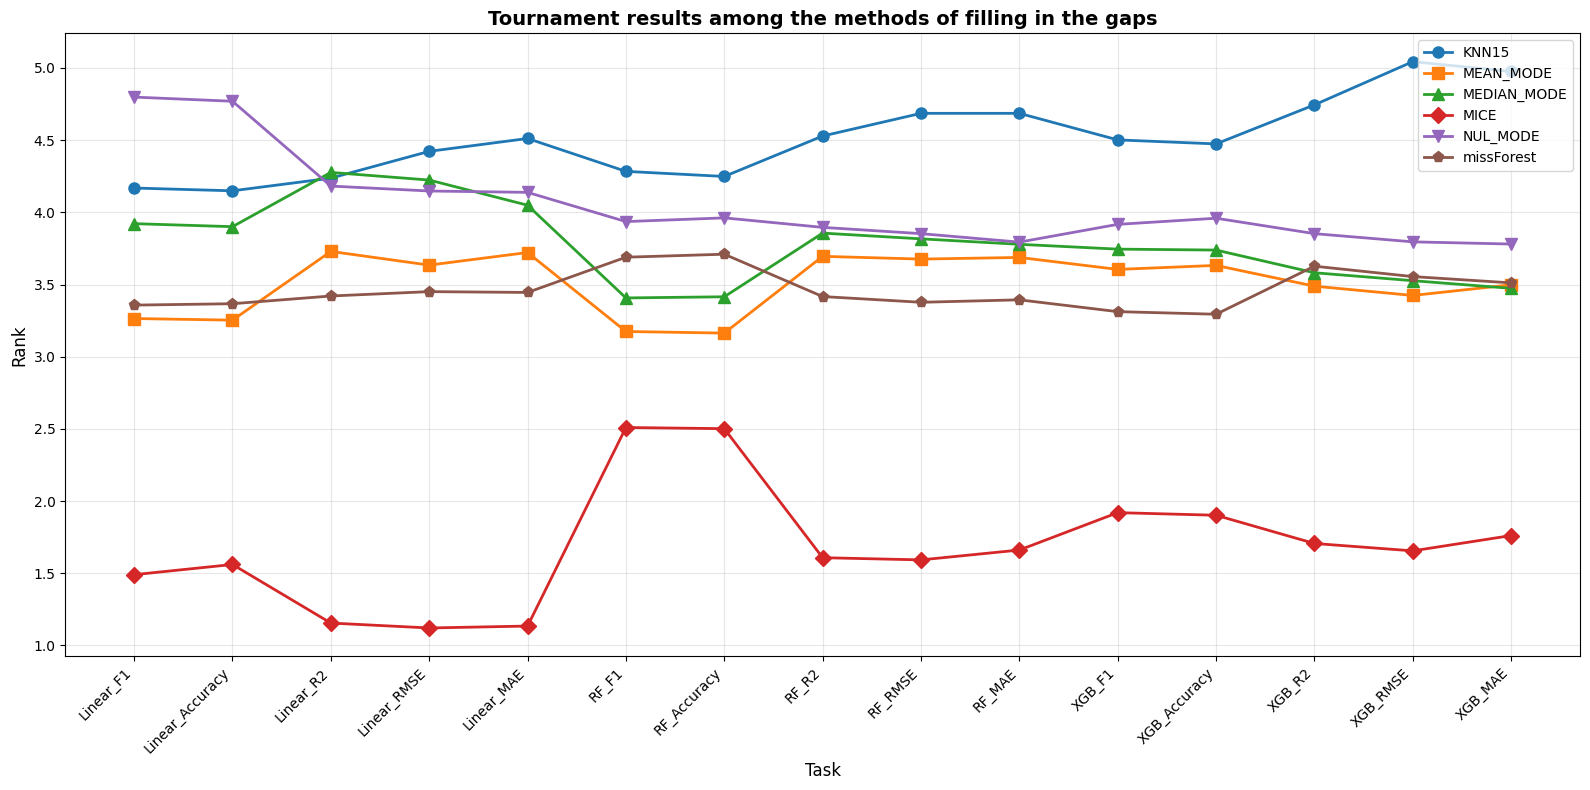

In [74]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(16, 8))

colors_method = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
markers = ['o', 's', '^', 'D', 'v', 'p']

for (method_name, values), color, marker in zip(y.items(), colors_method, markers):
    plt.plot(range(15), values, marker + '-', color=color, label=method_name, linewidth=2, markersize=8)

plt.xticks(range(15), x, rotation=45, ha='right')
plt.xlabel('Task', fontsize=12)
plt.ylabel('Rank', fontsize=12)
plt.title('Tournament results among the methods of filling in the gaps', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<font size="6">РЕЗУЛЬТАТЫ WMT.</font>

In [180]:
x = ['Linear_F1', 'Linear_Accuracy', 'Linear_R2', 'Linear_RMSE', 'Linear_MAE', 
           'RF_F1', 'RF_Accuracy', 'RF_R2', 'RF_RMSE', 'RF_MAE',
           'XGB_F1', 'XGB_Accuracy', 'XGB_R2', 'XGB_RMSE', 'XGB_MAE']

In [181]:
y = results_wmt.copy()

In [182]:
for key in y.keys():
    if key != 'MEDIAN_MODE':
        for value in results_rf_wmt[key]:
            y[key].append(value)
    else:
        for value in results_rf_wmt['MED_MODE']:
            y[key].append(value)

In [183]:
for key in y.keys():
    if key != 'MEDIAN_MODE':
        for value in results_xgb_wmt[key]:
            y[key].append(value)
    else:
        for value in results_xgb_wmt['MED_MODE']:
            y[key].append(value)

In [184]:
print(y)

{'KNN15': [2.594551282051282, 2.4743589743589745, 2.585227272727273, 2.327651515151515, 2.375, 2.9599358974358974, 2.891025641025641, 3.2708333333333335, 3.102272727272727, 3.0265151515151514, 2.6944444444444446, 2.5473856209150325, 3.2386363636363638, 3.2196969696969697, 3.0757575757575757], 'MEAN_MODE': [2.1955128205128207, 2.105769230769231, 2.441287878787879, 1.956439393939394, 2.0113636363636362, 2.2628205128205128, 2.2163461538461537, 2.600378787878788, 2.484848484848485, 2.4583333333333335, 2.0637254901960786, 1.9395424836601307, 2.2859848484848486, 2.375, 2.3106060606060606], 'MEDIAN_MODE': [2.266025641025641, 2.1426282051282053, 2.515151515151515, 2.2803030303030303, 2.195075757575758, 2.2836538461538463, 2.238782051282051, 2.679924242424242, 2.5625, 2.5208333333333335, 2.0947712418300655, 1.9558823529411764, 2.3125, 2.4015151515151514, 2.2859848484848486], 'MICE': [1.171474358974359, 1.1554487179487178, 1.1041666666666667, 1.0757575757575757, 1.0852272727272727, 1.64583333333

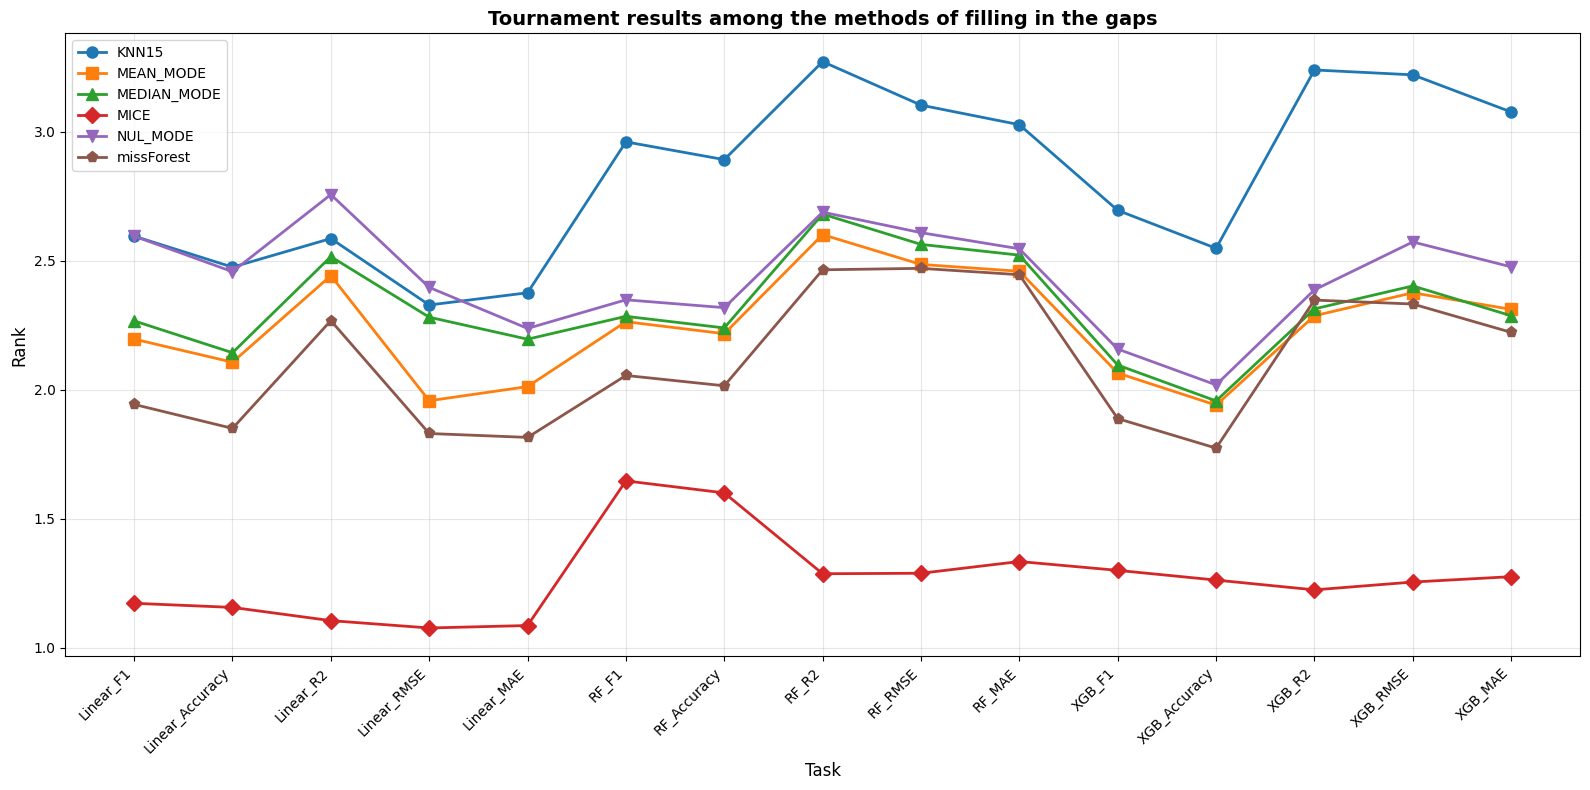

In [185]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(16, 8))

colors_method = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
markers = ['o', 's', '^', 'D', 'v', 'p']

for (method_name, values), color, marker in zip(y.items(), colors_method, markers):
    plt.plot(range(15), values, marker + '-', color=color, label=method_name, linewidth=2, markersize=8)

plt.xticks(range(15), x, rotation=45, ha='right')
plt.xlabel('Task', fontsize=12)
plt.ylabel('Rank', fontsize=12)
plt.title('Tournament results among the methods of filling in the gaps', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()